In [4]:
from transformers import AutoProcessor, AutoModelForCausalLM, AutoTokenizer

model_name = "internlm/Intern-S1-mini"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
len(tokenizer.tokenize('''Okay, let's see. I need to predict the oral bioavailability of a drug based on its SMILES structure. The question gives me the SMILES string:  <SMILES> CC1=CC(=NO1)NS(=O)(=O)C2=CC=C(C=C2)N  </SMILES> . The options are whether it has oral bioavailability less than 20% (A) or 20% or higher (B). 

First, I should recall what factors influence oral bioavailability. From what I remember, oral bioavailability is affected by several factors, including solubility, permeability, stability in the gastrointestinal tract, and first-pass metabolism. The structure of the molecule can give clues about these properties.

Looking at the SMILES structure: Let's break it down. The molecule has a 5-membered ring with a methyl group (CC1), an oxime group (N=O), and a sulfonamide group (NSO2) attached to a benzene ring (C2=CC=C(C=C2)N). The benzene ring has an amino group (N) attached. 

Sulfonamides are known to be somewhat polar, which might affect absorption. The presence of an oxime group could also contribute to polarity. Polar molecules tend to have lower permeability through the lipid membranes of the GI tract, which might lower bioavailability. However, the molecule doesn't seem extremely large, which is a plus for absorption. 

Another thing to consider is the presence of functional groups that are susceptible to metabolism. The amino group on the benzene ring could be a site for acetylation, which is a common metabolic reaction for aromatic amines. If the drug is metabolized extensively in the liver before reaching systemic circulation (first-pass effect), that could reduce bioavailability. However, the sulfonamide group might also be metabolized, but I'm not sure how significant that is.

Solubility is another factor. Sulfonamides can be somewhat soluble in water, especially if they have ionizable groups. The amino group might be protonated at physiological pH, which could increase solubility. However, the overall balance between hydrophilic and lipophilic parts in the molecule is important. If it's too hydrophilic, it might not cross the intestinal membrane well. 

I should also think about known drugs with similar structures. For example, sulfonamide antibiotics like sulfamethoxazole have good oral bioavailability. However, this molecule has an oxime group which is different. Oximes are sometimes used in drugs to improve certain properties, but they can also be metabolically unstable. 

Wait, but the presence of the oxime might lead to issues with stability in the GI tract. If the oxime is unstable in acidic conditions (like the stomach), the drug might break down before absorption. Alternatively, if it's stable, then maybe it's okay. 

Another approach is to use some rules of thumb for predicting bioavailability. The Lipinski's Rule of Five suggests that molecules with high molecular weight (>500), high logP (>5), many hydrogen bond donors (>2), or acceptors (>10) might have poor absorption. Let's calculate some of these parameters for this molecule.

The molecular formula can be determined from the SMILES. Let's count the atoms:

The SMILES is CC1=CC(=NO1)NS(=O)(=O)C2=CC=C(C=C2)N.

Breaking it down:

- The first part: CC1=CC(=NO1)N... So a 5-membered ring with two carbons (C1 and C), then a nitrogen (N) connected to the ring. Wait, maybe it's a furan or similar ring? Let me parse the SMILES more carefully.

The SMILES notation can be tricky. Let's parse it step by step:

The SMILES starts with CC1=CC(=NO1)NS(=O)(=O)... So:

- The first atom is C (carbon), connected to another C (methyl group?), then a ring closure with 1. So perhaps:

The first part is a ring where the first atom is C connected to another C (methyl?), then a double bond to C, which is connected to N=O (oxime group), and the ring closes with O. Wait, maybe the ring is C-C(=NO)-C=N-O? Not sure. Alternatively, the SMILES notation for rings uses numbers to indicate connections. Let me try to draw it mentally.

The SMILES string: CC1=CC(=NO1)NS(=O)(=O)C2=CC=C(C=C2)N.

Breaking it into parts:

- The first part: CC1=CC(=NO1)N. This suggests a ring where the first atom is a carbon (C) connected to another carbon (C) which is part of a ring (ring closure with 1). The first C is connected to a C which is double-bonded to another C (C=), which is connected to an N=O (oxime group), and the ring closes with O. Wait, perhaps the ring is a five-membered ring with atoms C, C, C, N, O? So the structure would be a 5-membered ring with a methyl group (from the first C), a double bond, and an oxime group. Then attached to this ring is an NH group connected to a sulfonyl group (S(=O)(=O)), which is attached to a benzene ring (C2=CC=C(C=C2)N), which has an amino group (N) at position 4 (assuming the sulfonyl is position 1).

So the molecule has a sulfonamide group linking two aromatic rings: one is a 5-membered ring with an oxime, and the other is a benzene ring with an amino group.

Now, molecular weight: Let's calculate it.

Atoms:

Ring1: Let's see. The first part is CC1=CC(=NO1)N. The ring would be:

C (from CC1) connected to C (ring member 1), then double bond to C (ring member 2), which is connected to N (ring member 3), which is connected to O (ring member 4), which connects back to ring member 1 (C). Wait, maybe not. The SMILES notation for rings uses numbers to denote connections. The first 'C' is outside the ring. Then 'C1' starts the ring. So:

The first 'C' is a methyl group attached to the ring. The ring is C1=CC(=NO1)N. So:

Ring atoms: C1, C, C, N, O1. So a five-membered ring. The first atom is C1, which is connected to a methyl group (from the initial CC1). Then C1 is double-bonded to C (position 2), which is connected to another C (position 3) double-bonded to N (position 4), which is connected to O (position 5), which closes back to C1. Hmm, not sure. Alternatively, the ring could be C1 connected to C (from the initial CC1), then C=CC(=NO1)N. Maybe it's a furan or similar structure.

Alternatively, perhaps the 5-membered ring is a 1,2-oxazole (isoxazole) ring. Isoxazoles have a structure with O and N adjacent. For example, the ring would be O-N-C-C-C. If the SMILES is CC1=CC(=NO1)N, then the ring would be O connected to N which is connected to a C, which is double-bonded to another C, which is connected to a C (with a methyl group), forming a five-membered ring. So the ring would be O-N-C=C-C (with a methyl group on the last C). That makes sense. So the first ring is a 5-membered isoxazole ring with a methyl group and an amino group attached.

Then the amino group (from the isoxazole) is connected to a sulfonyl group (SO2), which is attached to a benzene ring (C2=CC=C(C=C2)N), which has an amino group at the para position.

So the molecule has two aromatic rings connected by a sulfonamide group. The left ring is a methyl-substituted isoxazole with an amino group, and the right ring is aniline (aminobenzene).

Now, considering the molecular weight. Let's count all atoms:

Isoxazole ring: C (methyl) + ring atoms: O, N, C, C, C (with methyl). Wait, perhaps better to count all atoms in the molecule.

Breaking down the SMILES:

CC1=CC(=NO1)NS(=O)(=O)C2=CC=C(C=C2)N

- The first part: CC1=CC(=NO1)N: 

   - C (methyl) attached to C1.

   - C1 is part of a ring (ring 1), which is connected to C (position 2), which is double-bonded to C (position 3), which is connected to N (position 4), which is double-bonded to O (position 5), which connects back to C1.

   - Then, the N (position 4) is connected to the sulfonyl group.

Wait, maybe not. Let's parse the SMILES properly.

The SMILES notation is:

The first atom is C (carbon), which is connected to another C (carbon) which is part of a ring closure (1). Then, the ring is constructed as follows:

C1 (ring closure 1) is connected to C (from the initial CC1), then there's a double bond to C, which is connected to N=O, and the ring closes with O connected back to C1.

The exact structure might be a 5-membered ring with atoms: C (from CC1), C (ring member 1), C (ring member 2, double bond), N (ring member 3), O (ring member 4), and then back to ring member 1? Not sure. Alternatively, perhaps the ring is O-N-C-C-C with a methyl group.

Alternatively, perhaps the SMILES is better represented as:

The first part is a 5-membered ring with atoms O, N, C, C, C. The ring has a methyl group (from the initial CC1) and a substituent (the sulfonamide group) attached.

But maybe I'm overcomplicating. Let's focus on the functional groups. The molecule has:

- A sulfonamide group (NSO2), which is a common pharmacophore.

- Two aromatic rings: one is a 5-membered ring (possibly isoxazole with a methyl group), and the other is benzene with an amino group.

- The presence of two amino groups (on the benzene and attached to the sulfonamide) and the sulfonamide itself.

Now, considering the physicochemical properties:

1. Molecular Weight (MW): Let's calculate it.

The molecular formula:

Breaking down the SMILES:

CC1=CC(=NO1)NS(=O)(=O)C2=CC=C(C=C2)N

Let's count each atom:

- C: Let's see:

First part: CC1=CC(=NO1)N... So:

C (from the first C), C (from C1), then another C (from CC1=CC...), then another C (in the ring), then in the sulfonamide part: S(=O)(=O)C2=CC=C(C=C2)N.

Wait, perhaps better to write all atoms:

The SMILES can be broken down as:

C (methyl) attached to C1 (ring), which is connected to C (double bond), which is connected to N=O (oxime), then connected to N (which is part of the sulfonamide), then S(=O)(=O), then C2 (benzene ring), which has C=CC=C (with a double bond), and an amino group (N).

But perhaps a better approach is to count all atoms:

- Carbon (C):

   - The first C (methyl) in CC1...

   - C in C1 (ring)

   - C in the ring (CC(=NO1))

   - C in the benzene ring: C2, and the rest (4 more Cs in benzene, but considering substitution)

Wait, this is getting too confusing. Let's use a systematic approach.

The SMILES is CC1=CC(=NO1)NS(=O)(=O)C2=CC=C(C=C2)N.

Let's parse it step by step:

Start with the first atom: C (carbon). It's connected to another C (from the CC1 part). The second C is part of a ring (ring closure 1). Then, there's a double bond (C=), followed by C(=NO1)N. The C(=NO1) part indicates that the C is connected to N=O, and the ring closes with O connected back to the first ring closure (1). Then, the N is connected to S(=O)(=O), which is connected to C2 (another ring closure), followed by C=CC=C (with a double bond), and then (C=C2)N, which means that the benzene ring has a substituent N (amino group) and closes the ring at position 2.

So the molecule has two rings: a 5-membered ring (from the first part) and a benzene ring.

Calculating the molecular formula:

Let's count each atom:

- 5-membered ring (isoxazole derivative):

   - C: 3 (from CC1=CC... and the ring closure)

   - O: 1 (from the ring)

   - N: 2 (from N=O and the NH group attached to S)

Wait, perhaps not. Let's do it properly.

The SMILES can be broken into:

CC1=CC(=NO1)NS(=O)(=O)C2=CC=C(N)C=C2

Wait, perhaps the SMILES is equivalent to CC1=CC(=NO1)NS(=O)(=O)C2=CC=C(N)C=C2. Because the (C=C2)N would be the amino group attached to the benzene ring.

So the molecular formula would be:

C (from methyl) + C in the ring (C1) + C in the ring (C in CC(=NO1)) + C in the benzene ring (6 Cs) + S + O from sulfonamide (2) + O from isoxazole (1) + N from isoxazole (N in NO1) + N from sulfonamide (NH) + N from benzene's amino group.

Wait, this is getting complicated. Let's count each atom:

Carbon (C):

- Methyl group: 1 (the first C in CC1...)

- Isoxazole ring: 3 Cs (since it's a 5-membered ring with O and N; the ring has 3 Cs, 1 N, 1 O)

- Benzene ring: 6 Cs

Total C: 1 + 3 + 6 = 10?

Wait, but the benzene ring has a substituent (the sulfonamide group), which is attached to the isoxazole via the sulfonamide. So the benzene ring has 6 Cs, but one of them is connected to the S. So total C count:

Isoxazole ring: 3 (including the methyl group?) Wait, the isoxazole ring is a 5-membered ring with O and N. The SMILES for isoxazole is C1=CON=C1. So substituting at positions 3 and 5 perhaps. The SMILES given is CC1=CC(=NO1)N... So the isoxazole has a methyl group (C) at position 5 (if numbering starts at O as 1), and an amino group attached to the sulfonamide at position 3.

So the isoxazole ring has 3 Cs (including the methyl), 1 N, 1 O. So total C in isoxazole: 3 (including the methyl). Then the benzene ring has 6 Cs. So total C: 3 + 6 = 9? But the methyl is part of the isoxazole's C count.

Wait, maybe the molecular formula is C10H11N3O3S.

Wait, let's check:

The SMILES is CC1=CC(=NO1)NS(=O)(=O)C2=CC=C(N)C=C2.

Breaking it down:

- CC1=CC(=NO1)N: 

   - The isoxazole ring (C3H3NO) with a methyl group (CH3) and an amino group attached to the sulfonamide.

   - The ring itself has 3 carbons, 1 nitrogen, 1 oxygen.

   - The methyl group adds 1 C and 3 H.

   - The NH group attached to S has 1 N and 1 H.

- Sulfonamide: SO2NH- (but connected to the benzene)

- Benzene ring (C6H5) with an amino group (NH2) at position 4.

Putting it all together:

Carbons: 3 (isoxazole) + 1 (methyl) + 6 (benzene) = 10.

Hydrogens: Let's see. The isoxazole ring with a methyl and NH group: assuming the ring has two double bonds, the H count on the ring might be 1 (on the C adjacent to O). The methyl has 3 H. The NH group has 1 H. The benzene ring with an amino group would have 4 H (since one position is substituted with NH2). The sulfonamide's NH has 1 H. The amino group on benzene has 2 H. So total H:

Isoxazole ring: 1 (on C) + methyl 3 + NH (1) = 5.

Benzene ring: 4 (since two substituents: sulfonamide and NH2, but wait, the benzene has sulfonamide at position 1 and NH2 at position 4. So each substituent replaces an H. Benzene normally has 6 H. With two substituents, 4 H left. Then the amino group has 2 H, and the sulfonamide's NH has 1 H. So total H:

5 (from isoxazole part) + 4 (benzene) + 2 (NH2) + 1 (sulfonamide NH) = 12. But also, the benzene's sulfonamide NH is part of the chain. Wait, the sulfonamide is N connected to the isoxazole and the S. So the sulfonamide's NH is part of the connection. So the H count might be:

Isoxazole part: methyl (3H) + ring H (maybe 1H) + NH (1H) = 5H.

Benzene part: 4H (on the ring) + NH2 (2H) = 6H.

Sulfonamide: the NH has 1H.

Wait, but the sulfonamide group is N connected to the isoxazole and the S. The sulfonamide's NH would have one H. So total H:

5 (from isoxazole side) + 4 (benzene ring) + 2 (NH2) + 1 (sulfonamide NH) = 12. But I'm not sure. Alternatively, the molecular formula could be C10H11N3O3S. Let's check:

C: 10

H: Let's count again. The isoxazole ring with methyl and NH group: the ring has two double bonds. The methyl has 3H. The NH has 1H. The benzene ring with two substituents (sulfonamide and NH2) would have 4H. The sulfonamide's NH has 1H. The NH2 has 2H. So total H: 3 (methyl) + 1 (ring H) + 1 (NH) + 4 (benzene) + 2 (NH2) + 1 (sulfonamide NH) = 12H. But maybe the ring has more H. Alternatively, perhaps the isoxazole ring has no additional H. This is getting too time-consuming. Maybe I should proceed with approximate values.

Molecular weight calculation:

C: 10 * 12 = 120

H: ~11 (assuming 11) * 1 = 11

N: 3 (from isoxazole N, sulfonamide N, and benzene NH2) → Wait, the isoxazole has one N (in the ring), the sulfonamide N, and the benzene's NH2. Wait, no: the isoxazole ring has two N atoms? No, isoxazole has one N. Wait, the SMILES has N in the ring (from NO1), so the ring has O and N. So the isoxazole ring has one O and one N. Then the sulfonamide has an N connected to the ring. So total N atoms: 1 (ring) + 1 (sulfonamide) + 1 (benzene NH2) = 3 N.

O: O in isoxazole ring (1) + O in sulfonamide (2) = 3 O.

S: 1.

So molecular formula is C10H11N3O3S.

Calculating MW:

C: 10*12=120

H: 11*1=11

N: 3*14=42

O: 3*16=48

S: 32

Total MW = 120 + 11 +42 +48 +32 = 253 g/mol. That's under 500, so Lipinski's rule for MW is okay.

Hydrogen bond donors (HBD): The sulfonamide NH (1), the benzene NH2 (2), and any other NH? The isoxazole ring doesn't have HBDs except maybe the NH attached to the sulfonamide. Wait, the sulfonamide NH is one HBD. The benzene's NH2 is two HBDs. Are there any others? The oxime group (N=O) doesn't contribute as a donor. So total HBDs: 3 (1 from sulfonamide NH, 2 from NH2).

Hydrogen bond acceptors (HBA): The O in isoxazole (1), the two O in sulfonamide (2), the N in isoxazole ring (1), the sulfonamide N (1), and the benzene's NH2 N (1). Wait, but HBA counts usually consider N and O atoms. So:

O: 3 (isoxazole O, two sulfone O's)

N: three N's (isoxazole ring N, sulfonamide N, benzene NH2 N). Wait, but the sulfonamide N is connected to the S, and the benzene's NH2 is a primary amine.

So total HBA: 3 O + 3 N = 6.

Lipinski's rule says HBA ≤ 10 and HBD ≤ 5. So this molecule passes both. MW is 253 < 500. So according to Lipinski's rule, it should have good absorption. But Lipinski's rule is more about permeability and solubility. However, sulfonamides can be tricky. They are often hydrophilic, which might reduce permeability. But the molecule's logP (partition coefficient) is also a factor. If the logP is too low (too hydrophilic), it may not cross the intestinal membrane well.

What's the logP of this molecule? Without calculating, we can estimate. The molecule has several polar groups: sulfonamide, amino, oxime, and aromatic rings. The presence of the methyl group adds some lipophilicity. Sulfonamides typically have moderate logP values. For example, sulfamethoxazole has a logP around 0.9. If this molecule's logP is similar, it might be okay. However, the presence of two amino groups (which are ionizable) could affect this. At physiological pH (around 7.4), the sulfonamide NH (pKa around 10-11) might be mostly unionized, but the aniline NH2 (pKa around 4-5) would be protonated (positively charged). The oxime group's pKa varies, but if it's deprotonated or not depends on the pH. A charged molecule has lower permeability.

The benzene's amino group (aniline) has a pKa around 4-5. At pH 7.4, it would be protonated (NH3+), making the molecule charged. Charged molecules have lower membrane permeability, which could reduce oral absorption. However, if the molecule has enough lipophilicity to balance the charge, it might still be absorbed.

Another consideration is the presence of the sulfonamide group, which is known to be a hydrogen bond donor and acceptor, contributing to high solubility but potentially low permeability. However, some sulfonamides have good oral bioavailability.

In terms of metabolic stability, the aniline group could be subject to acetylation, but that's a phase II reaction which might not significantly affect first-pass metabolism unless the acetylation is rapid. The oxime group could be metabolically unstable, but I'm not certain.

Comparing to known drugs: Sulfonamides like sulfadiazine have oral bioavailability around 70%, which is good. However, if this molecule has a charged group at physiological pH (the aniline NH3+), it might have lower absorption. But the overall molecule's balance of properties might still allow for decent absorption.

Alternatively, the presence of the oxime might lead to instability in the GI tract. If the oxime is hydrolyzed or degraded in the stomach's acidic environment, then the bioavailability could be low. However, oximes can be stable under certain conditions.

Another angle: the molecule's polar surface area (PSA). PSA is the sum of the surface areas of polar atoms (O, N, etc.). High PSA (>90 Å²) is associated with lower permeability. Let's estimate PSA. The molecule has:

- 3 O atoms (isoxazole O, two sulfone O's) contributing ~ each around 30-40 Å².

- 3 N atoms (ring N, sulfonamide N, aniline N). The aniline NH2 has a higher PSA than the sulfonamide N.

But exact calculation is hard without software. However, sulfonamides typically have high PSA. For example, sulfamethoxazole has PSA around 100 Å². If this molecule's PSA is similar, it might have lower permeability.

Putting this all together:

- MW is acceptable.

- HBD and HBA within Lipinski's limits.

- Possible charge at physiological pH (NH3+ on benzene), which could reduce permeability.

- High PSA, which may reduce absorption.

- Potential metabolic issues (acetylation of aniline), but not certain.

If the molecule has low permeability due to charge and high PSA, then oral bioavailability could be low. However, some sulfonamides with similar properties have good bioavailability. The presence of the oxime and methyl group might add some lipophilicity.

Alternatively, looking up the actual drug: Wait, the SMILES given is  <SMILES> CC1=CC(=NO1)NS(=O)(=O)C2=CC=C(C=C2)N  </SMILES> . If I recall correctly, this structure resembles sulfisoxazole, which is a sulfonamide antibiotic. Sulfisoxazole has a bioavailability of around 70% after oral administration. If that's the case, then the answer would be B (≥20%). But wait, sulfisoxazole's structure is similar: it's a sulfonamide with an isoxazole ring. Yes, sulfisoxazole has a 5-methylisoxazole group attached to the sulfonamide. And its oral bioavailability is indeed high. So if this SMILES corresponds to sulfisoxazole, then the answer is B.

But wait, the SMILES given has an amino group on the benzene ring. Sulfisoxazole's structure is sulfonamide connected to a benzene ring without an amino group. Wait, maybe I'm confusing the structure. Let me check:

Sulfisoxazole's SMILES is CC1=CC(C)=C(S(=O)(=O)NC2=CC=C(N)C=C2)O1? No, wait. Alternatively, sulfisoxazole's SMILES is CC1=CC(C)=C(S(N)(=O)=O)O1. No, perhaps not. Alternatively, sulfisoxazole is N-(5-methylisoxazol-3-yl)-4-aminobenzenesulfonamide. Which would match the given SMILES: the benzene ring has an amino group (4-position), and the isoxazole has a methyl group. Yes, that's correct. So the given SMILES is sulfisoxazole, which has high oral bioavailability. Therefore, the answer should be B.
 </think> 

Answer: (B)'''))

6257

In [2]:
from transformers import AutoProcessor, AutoModelForCausalLM, AutoTokenizer

model_name = "internlm/Intern-S1-mini"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.tokenize('(A)')

['(A', ')']

In [8]:
from transformers import AutoProcessor, AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen3-8B"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.tokenize(' (A)')

['Ġ(', 'A', ')']

In [4]:
for i in tokenizer.tokenize('MVPSAGQLALFALGIVLAACQALENSTSPLSADPPVAAAVVSHFNDCPDSHTQFCFHGTCRFLVQEDKPACVCHSGYVGARCEHADLLAVVAASQKKQAITALVVVSIVALAVLIITCVLIHCCQVRKHCEWCRALICRHEKPSALLKGRTACCHSETVV*MVPSAGQLALFALGIVLAACQALENSTSPLSDPPVAAAVVSHFNDCPDSHTQFCFHGTCRFLVQEDKPACVCHSGYVGARCEHADLLAVVAASQKKQAITALVVVSIVALAVLIITCVLIHCCQVRKHCEWCRALICRHEKPSALLKGRTACCHSETVV*XPPVAAAVVSHFNDCPDSHTQFCFHGTCRFLVQEDKPACVCHSGYVGARCEHADLLAVVAASQKKQAITALVVVSIVALAVLIITCVLIHCCQVRKHCEWCRALICRHEKPSALLKGRTACCHSETGCRLY*MVPSAGQLALFALGIVLAACQALENSTSPLSDPPVAAAVVSHFNDCPDSHTQFCFHGTCRFLVQEDKPACVCHSGYVGARCEHADLLAVVAASQKKQAITALVVVSIVALAVLIITCVLIMFKIGRGALDLFSELLSFGGIVLAACQALENSTSPLSADPPVAAAVVSHFNDCPDSHTQFCFHGTCRFLVQEDKPACVCHSGYVGARCEHADLLAVVAASQKKQAITALVVVSIVALAVLIITCVLIHCCQVRKHCEWCRALICRHEKPSALLKGRTACCHSETVV*MVPSAGQLALFALGIVLAACQALENSTSPLSDPPVAAAVVSHFNDCPDSHTQFCFHGTCRFLVQEDKPACVCHSGYVGARCEHADLLAVVAASQKKQAITALVVVSIVALAVLIITCVLIHCCQVRKHCEWCRALICRHEKPSALLKGRTACCHSETATLG*MFKIGRGALDLFSELLSFGGIVLAACQALENSTSPLSDPPVAAAVVSHFNDCPDSHTQFCFHGTCRFLVQEDKPACVCHSGYVGARCEHADLLAVVAASQKKQAITALVVVSIVALAVLIITCVLIHCCQVRKHCEWCRALICRHEKPSALLKGRTACCHSETVV*'):
    if i == '<FASTA_AUTO_DETECT>':
        print(i)

<FASTA_AUTO_DETECT>
<FASTA_AUTO_DETECT>
<FASTA_AUTO_DETECT>
<FASTA_AUTO_DETECT>
<FASTA_AUTO_DETECT>
<FASTA_AUTO_DETECT>


In [5]:
record = {
    "instruction": "计算这些物品的总费用。",
    "input": "汽车-3000，衣服-100，书-20",
    "output": "总费用为 3120。"
}
user_text = (record["instruction"] + ("\n" + record["input"] if record.get("input") else "")).strip()
messages = [
    # {"role": "system", "content": record.get("system", "")},   # 可无
    {"role": "user",   "content": user_text},
    # {"role": "assistant", "content": record["output"]}         # 训练时 labels 只覆盖回答部分
]
rendered = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    enable_thinking=False,
    add_generation_prompt=True   # 训练样本里通常不加“等待助手回复”的尾部
)
print("===Rendered text===")
print(rendered)
print("===Rendered text===")

===Rendered text===
<|im_start|>user
计算这些物品的总费用。
汽车-3000，衣服-100，书-20<|im_end|>
<|im_start|>assistant

===Rendered text===


In [3]:
record = {
    "instruction": "计算这些物品的总费用。",
    "input": "汽车-3000，衣服-100，书-20",
    "output": "总费用为 3120。"
}

# 你自己写好的reasoning
reasoning = """1. 汽车 3000
2. 衣服 100
3. 书 20
4. 合计 3000 + 100 + 20 = 3120"""

user_text = (record["instruction"] + ("\n" + record["input"] if record.get("input") else "")).strip()

messages = [
    {"role": "user", "content": user_text},
    {
        "role": "assistant",
        "content": f"<think>\n{reasoning}\n</think>\n{record['output']}"
    }
]

rendered = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    enable_thinking=True,   # 关键：关掉它自动插空<think>的功能
    add_generation_prompt=False
)

print(rendered)


<|im_start|>system
You are an expert reasoner with extensive experience in all areas. You approach problems through systematic thinking and rigorous reasoning. Your response should reflect deep understanding and precise logical thinking, making your solution path and reasoning clear to others. Please put your thinking process within <think>...</think> tags.<|im_end|>
<|im_start|>user
计算这些物品的总费用。
汽车-3000，衣服-100，书-20<|im_end|>
<|im_start|>assistant
<think>
1. 汽车 3000
2. 衣服 100
3. 书 20
4. 合计 3000 + 100 + 20 = 3120
</think>
总费用为 3120。<|im_end|>



In [4]:
model_name = "internlm/Intern-S1-mini"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

placeholder = "<IMG_CONTEXT>"
question = "What is the main function of this protein?"

messages = [
    [{"role": "user", "content": f"{placeholder}\n{question}"}]
]
prompts = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)

print(prompts)

['<|im_start|>system\nYou are an expert reasoner with extensive experience in all areas. You approach problems through systematic thinking and rigorous reasoning. Your response should reflect deep understanding and precise logical thinking, making your solution path and reasoning clear to others. Please put your thinking process within <think>...</think> tags.<|im_end|>\n<|im_start|>user\n<IMG_CONTEXT>\nWhat is the main function of this protein?<|im_end|>\n<|im_start|>assistant\n<think>']


In [7]:
tokenizer.additional_special_tokens

['<|im_start|>',
 '<|im_end|>',
 '<|object_ref_start|>',
 '<|object_ref_end|>',
 '<|box_start|>',
 '<|box_end|>',
 '<|quad_start|>',
 '<|quad_end|>',
 '<|vision_start|>',
 '<|vision_end|>',
 '<|vision_pad|>',
 '<|image_pad|>',
 '<|video_pad|>']

In [9]:
tokenizer.all_special_tokens

['<|im_end|>',
 '<|endoftext|>',
 '<|im_start|>',
 '<|object_ref_start|>',
 '<|object_ref_end|>',
 '<|box_start|>',
 '<|box_end|>',
 '<|quad_start|>',
 '<|quad_end|>',
 '<|vision_start|>',
 '<|vision_end|>',
 '<|vision_pad|>',
 '<|image_pad|>',
 '<|video_pad|>',
 '<IMG_CONTEXT>',
 '</img>',
 '<img>',
 '<video>']

In [11]:
tokenizer.get_added_vocab()

{'<|endoftext|>': 151643,
 '<|im_start|>': 151644,
 '<|im_end|>': 151645,
 '<|object_ref_start|>': 151646,
 '<|object_ref_end|>': 151647,
 '<|box_start|>': 151648,
 '<|box_end|>': 151649,
 '<|quad_start|>': 151650,
 '<|quad_end|>': 151651,
 '<|vision_start|>': 151652,
 '<|vision_end|>': 151653,
 '<|vision_pad|>': 151654,
 '<|image_pad|>': 151655,
 '<|video_pad|>': 151656,
 '<tool_call>': 151657,
 '</tool_call>': 151658,
 '<|fim_prefix|>': 151659,
 '<|fim_middle|>': 151660,
 '<|fim_suffix|>': 151661,
 '<|fim_pad|>': 151662,
 '<|repo_name|>': 151663,
 '<|file_sep|>': 151664,
 '<tool_response>': 151665,
 '</tool_response>': 151666,
 '<think>': 151667,
 '</think>': 151668,
 '<SMILES>': 151925,
 '</SMILES>': 151926,
 '<SELFIES>': 151927,
 '</SELFIES>': 151928,
 '<IUPAC>': 152441,
 '</IUPAC>': 152442,
 '<FASTA>': 152955,
 '</FASTA>': 152956,
 '<IMG_CONTEXT>': 152957,
 '<img>': 152958,
 '</img>': 152959,
 '<quad>': 152960,
 '</quad>': 152961,
 '<ref>': 152962,
 '</ref>': 152963,
 '<box>': 152

CCC(O)C(CO)CO


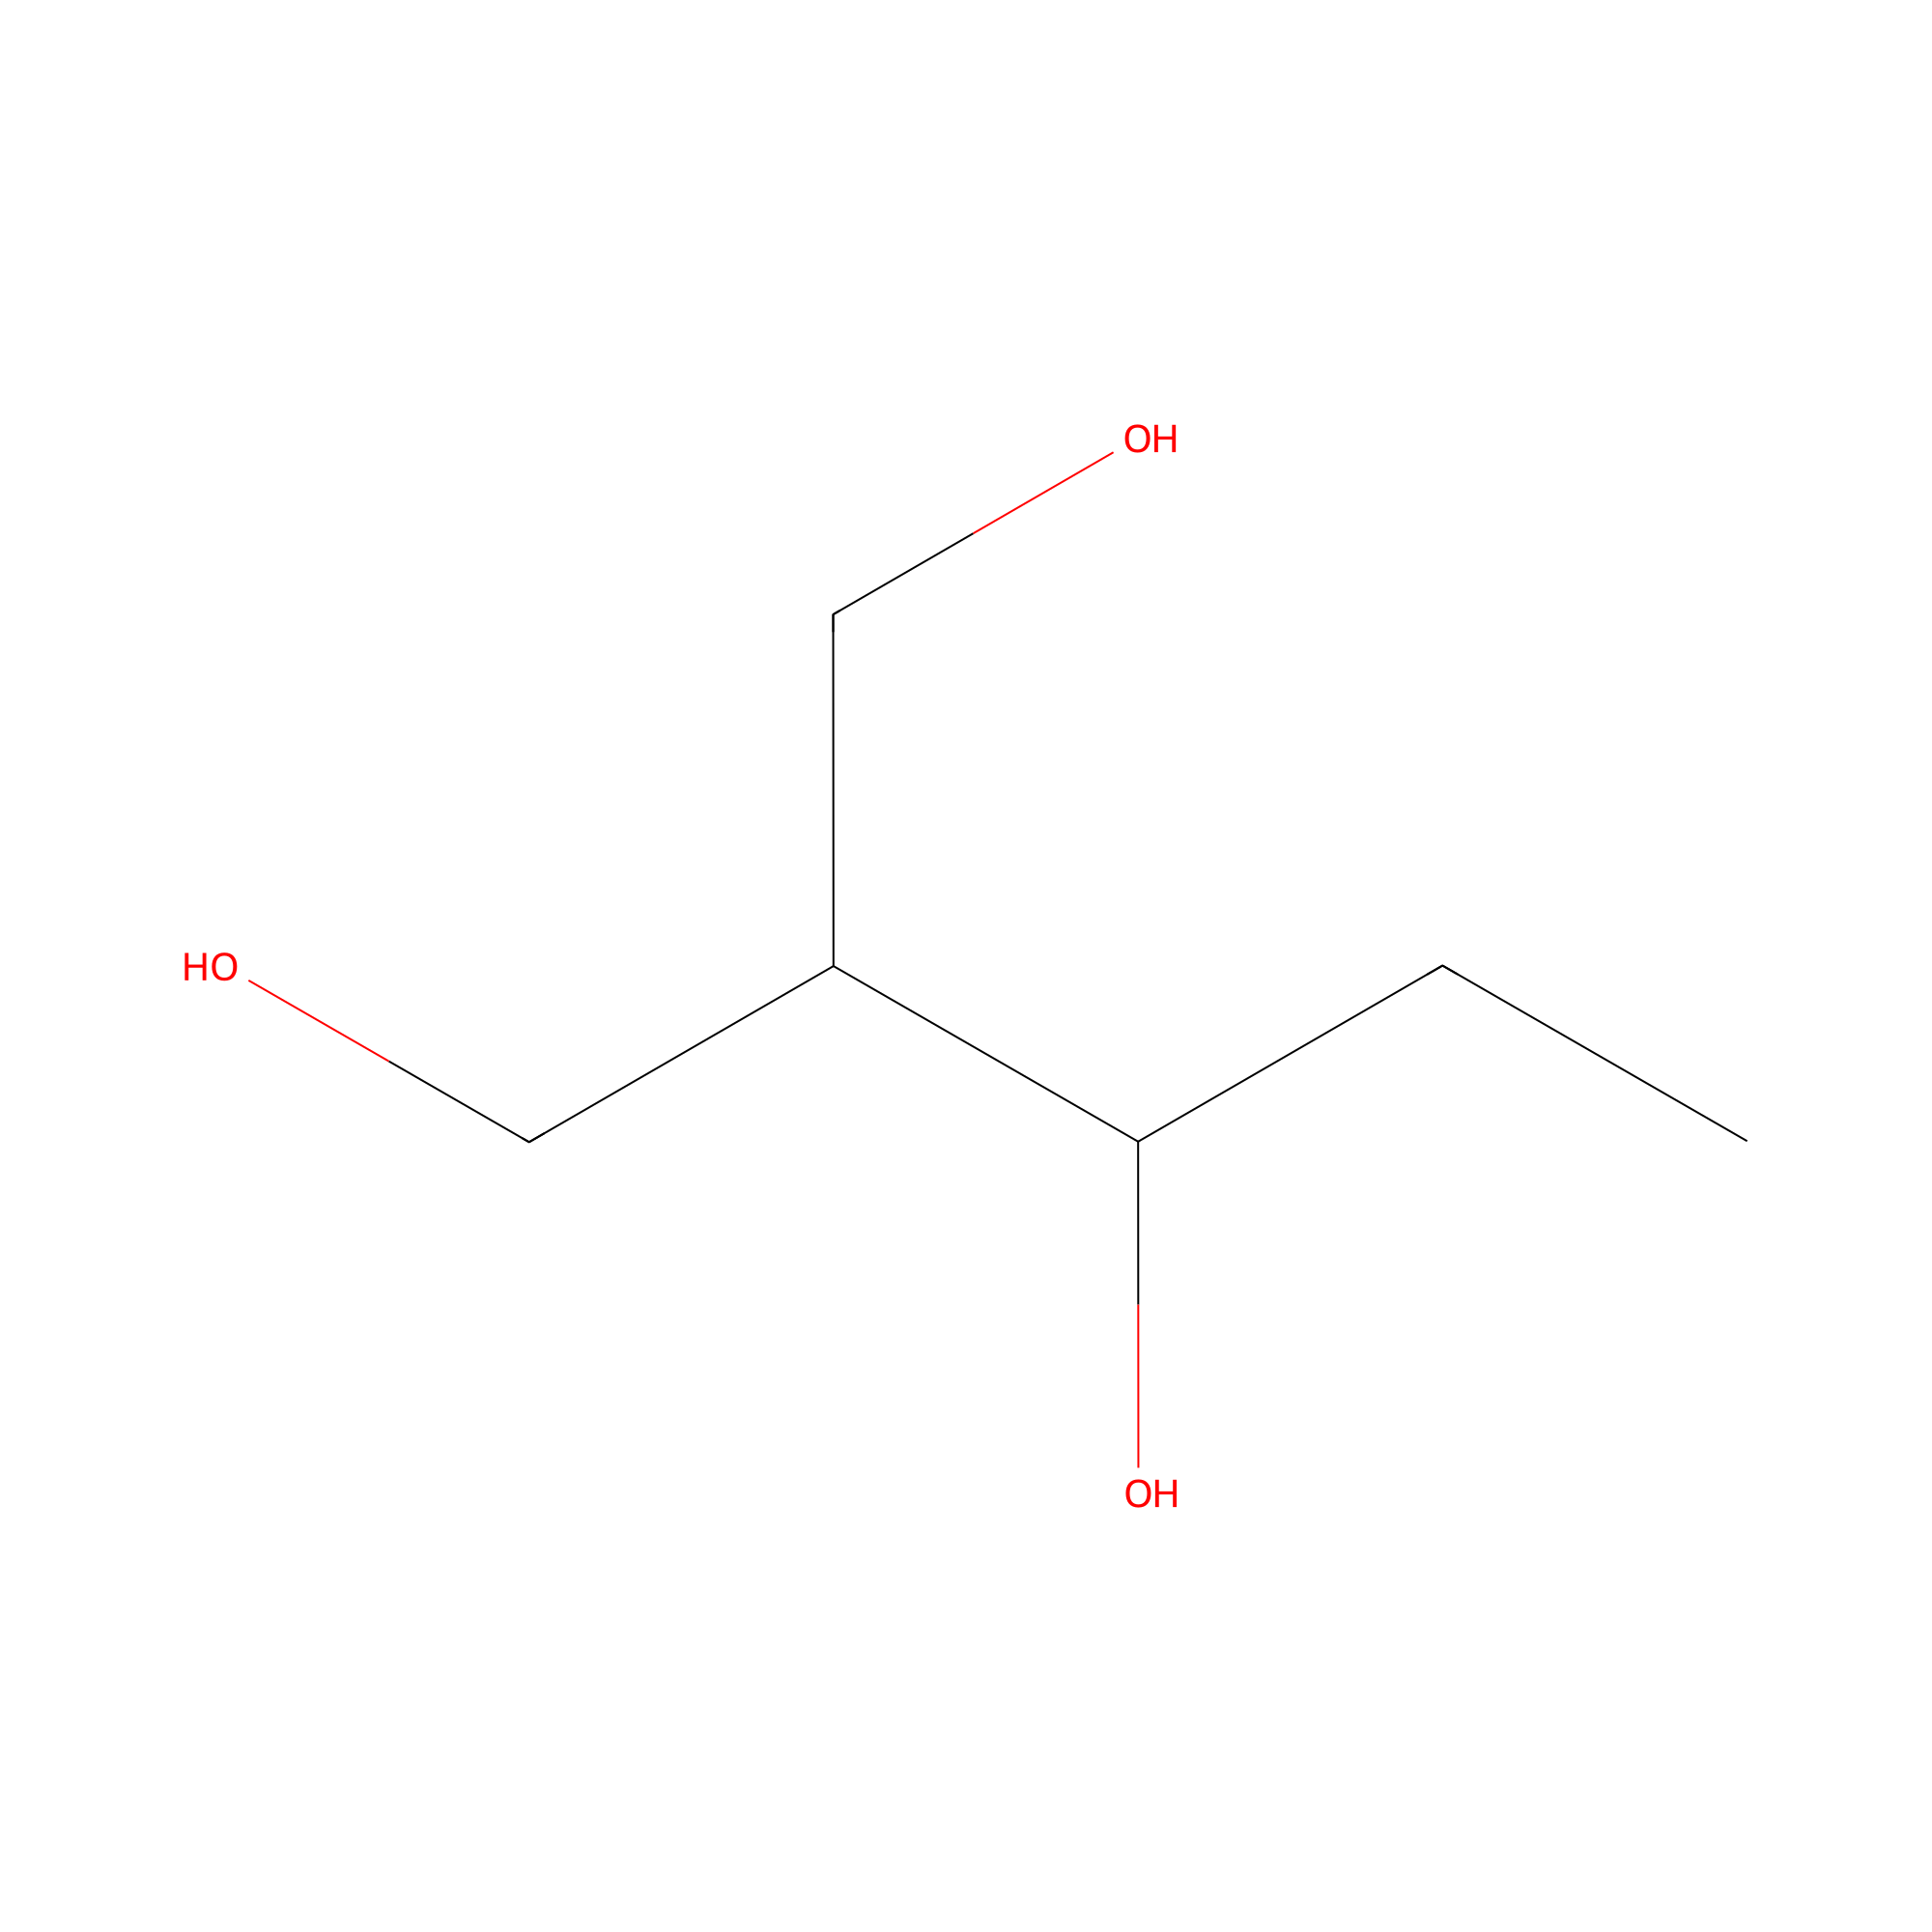

In [1]:
from rdkit import Chem
from rdkit.Chem import Draw
# import selfies as sf
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import MolDrawOptions

# 使用从 OPSIN 获得的 SMILES
smiles = "CCC(O)C(CO)CO"
# smiles = "[C][=O][N]"
# C[N+](C)(C)CCCC[C@@H](C(=O)[O-])[NH3+]
# smiles = sf.decoder(smiles)
print(smiles)
# 创建分子对象
mol = Chem.MolFromSmiles(smiles)

rdDepictor.SetPreferCoordGen(True)
rdDepictor.Compute2DCoords(mol)

opts = MolDrawOptions()
# opts.reduceOverlap = True

# 绘制分子结构
img = Draw.MolToImage(mol, size=(2000, 2000))
display(img)

CCC(O)C(CO)CO


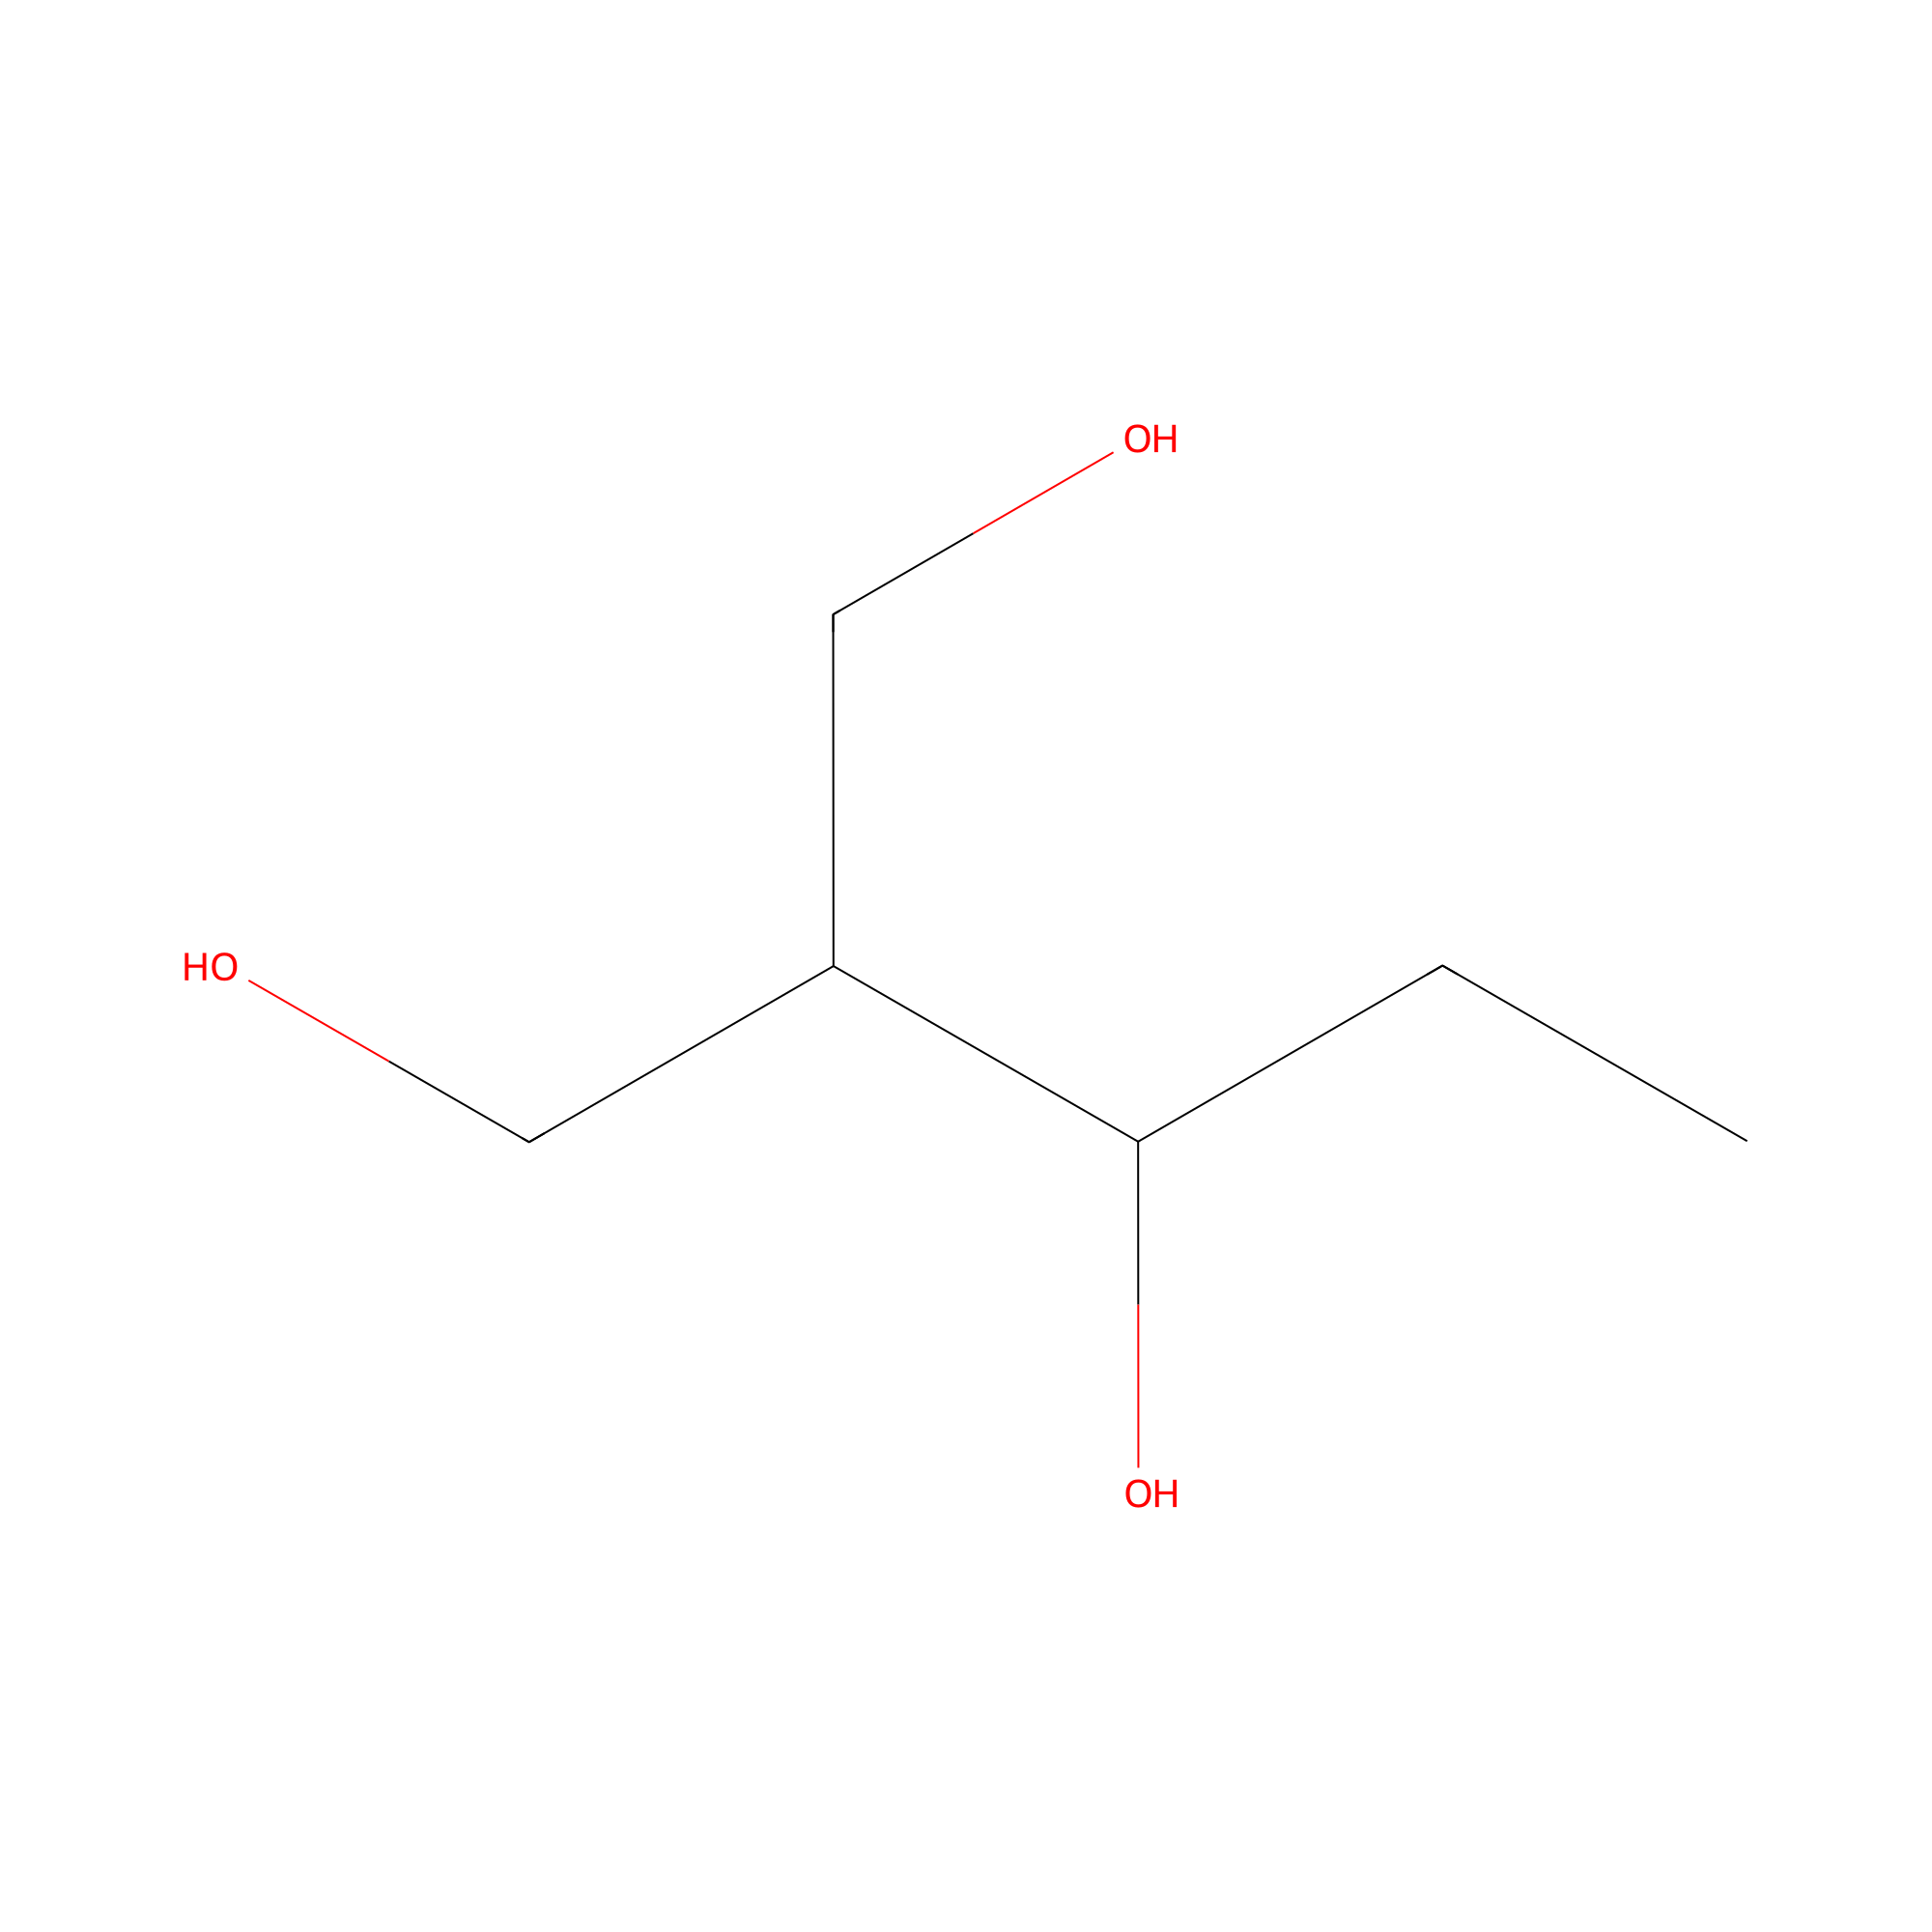

In [2]:
from rdkit import Chem
from rdkit.Chem import Draw
# import selfies as sf
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import MolDrawOptions

# 使用从 OPSIN 获得的 SMILES
smiles = "CCC(O)C(CO)CO"
# smiles = "[C][=O][N]"
# C[N+](C)(C)CCCC[C@@H](C(=O)[O-])[NH3+]
# smiles = sf.decoder(smiles)
print(smiles)
# 创建分子对象
mol = Chem.MolFromSmiles(smiles)

rdDepictor.SetPreferCoordGen(True)
rdDepictor.Compute2DCoords(mol)

opts = MolDrawOptions()
# opts.reduceOverlap = True

# 绘制分子结构
img = Draw.MolToImage(mol, size=(2000, 2000))
display(img)

In [12]:
tokenizer.tokenize('<|im_start|>user\nInstructions: Answer the following question about drug properties.\nContext: As a membrane separating circulating blood and brain extracellular fluid, the blood-brain barrier (BBB) is the protection layer that blocks most foreign drugs. Thus the ability of a drug to penetrate the barrier to deliver to the site of action forms a crucial challenge in development of drugs for central nervous system.\nQuestion: Given a drug SMILES string, predict whether it\n(A) does not cross the BBB (B) crosses the BBB\nDrug SMILES: <SMILES>CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](CC[C@@H]3C[C@@H](O)CC(=O)O3)[C@H]21</SMILES>\nAnswer:<|im_end|>\n<|im_start|>assistant\n(A')[142]

'(A'

看看image的情况下template是什么样的

In [1]:
from transformers import AutoProcessor, AutoModelForCausalLM
import torch

model_name = "internlm/Intern-S1-mini"
processor = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype="auto", trust_remote_code=True)

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": "http://images.cocodataset.org/val2017/000000039769.jpg"},
            {"type": "text", "text": "Please describe the image explicitly."},
        ],
    }
]

inputs = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt").to(model.device, dtype=torch.bfloat16)

print(inputs)
generate_ids = model.generate(**inputs, max_new_tokens=32768)
decoded_output = processor.decode(generate_ids[0, inputs["input_ids"].shape[1] :], skip_special_tokens=True)
print(decoded_output)


/data1/tianang/anaconda3/envs/intern/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
A new version of the following files was downloaded from https://huggingface.co/internlm/Intern-S1-mini:
- processing_interns1.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/internlm/Intern-S1-mini:
- modeling_interns1.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

ValueError: Could not make a flat list of images from [['http://images.cocodataset.org/val2017/000000039769.jpg']]

In [1]:
from tdc.single_pred import ADME, Tox, QM, Epitope, Develop, CRISPROutcome, Yields
from tdc.multi_pred.ppi import PPI#, TCREpitopeBinding, TrialOutcome, PeptideMHC
from tdc.multi_pred.tcr_epi import TCREpitopeBinding
from tdc.multi_pred.trialoutcome import TrialOutcome
from tdc.multi_pred.peptidemhc import PeptideMHC
from tdc.multi_pred.dti import DTI
from tdc.multi_pred.drugsyn import DrugSyn
from tdc.multi_pred.drugres import DrugRes
from tdc.multi_pred.antibodyaff import AntibodyAff
from huggingface_hub import hf_hub_download
import json
import numpy as np
from tdc.utils import retrieve_label_name_list
print(1)

tdc_prompts_filepath = hf_hub_download(
    repo_id="google/txgemma-9b-predict",
    filename="tdc_prompts.json",
)
tdc_prompts_json = json.load(open(tdc_prompts_filepath))


# 选择一个任务和输入
task_name = "CYP1A2_Veith"  # BBB_Martins
# label_list = retrieve_label_name_list(task_name)
# print(label_list)
input_type = "{Drug SMILES}"

# SFT_data = Tox(name=task_name, label_name = label_list[2])
data = ADME(name=task_name)
# SFT_data = SFT_data.neg_sample(frac = 1)  # only for PPI dataset
split = data.get_split()
print(split['test'])
# print((split['test']['Y'].to_numpy()).sum())#[:5]
# print(split['test']['Antibody'].values)
test_drugs = split['test']['Drug']#[:5]
test_labels = split['test']['Y']#[:5]

drug_smiles = test_drugs[0]

prompt_text = tdc_prompts_json[task_name].replace(input_type, f'<SMILES>{drug_smiles}</SMILES>')
print(prompt_text)
conv = [{"role": "user", "content": [{"type": "text", "text": prompt_text}]}]
tokenizer.apply_chat_template(
            conv,
            tokenize=False,  # 让 vLLM 自己分词
            add_generation_prompt=True,  # 补上assistant起始标记
            enable_thinking=False
        )

Downloading...


1


100%|██████████| 760k/760k [00:00<00:00, 2.45MiB/s]
Loading...
Done!


         Drug_ID                                               Drug  Y
0       700531.0        O=C(O)[C@H](Cc1cnc[nH]1)N1C(=O)c2ccccc2C1=O  0
1      6270538.0            COc1ccc(CNC(=O)/C=C/c2ccc(OCCCF)cc2)cc1  0
2      3239491.0                            CC(=O)NC(O)C(=O)c1ccco1  0
3      5771786.0               CCCC/C=C/C(NC(=O)CCc1ccccc1)c1ccccc1  1
4       738566.0                      COc1cccc(CNCc2ccc(SC)cc2)c1OC  1
...          ...                                                ... ..
2511   3435952.0             O=C(Nc1nnc(SCc2c(Cl)cccc2Cl)s1)C1CCCO1  1
2512   3246557.0                    O=C(O)[C@@H](Br)[C@H](Br)C(=O)O  0
2513  16758750.0  COc1ccc(COC(=O)N/N=C2/C[C@@H](O)[C@@H](O)[C@@H...  0
2514    135349.0  CN(C(=O)Cc1ccc(Cl)c(Cl)c1)[C@@H]1CCCC[C@H]1N1C...  0
2515   2295127.0  Cc1ccc(S(=O)(=O)Oc2ccc(C3C4=C(CCCC4=O)OC4=C3C(...  0

[2516 rows x 3 columns]
Instructions: Answer the following question about drug properties.
Context: The CYP P450 genes are involved in the formatio

NameError: name 'tokenizer' is not defined

In [3]:
tdc_prompts_json['MHC1_IEDB_IMGT_Nielsen']

'Instructions: Answer the following question about peptide-MHC binding.\nContext: In the human body, T cells monitor the existing peptides and trigger an immune response if the peptide is foreign. To decide whether or not if the peptide is not foreign, the peptide must bind to a major histocompatibility complex (MHC) molecule. Therefore, predicting peptide-MHC binding affinity is pivotal for determining immunogenicity. In some experiments, the peptide binding is measured against cells that express multiple MHCs, so the peptide could be binding any one of the possible MHCs. Class 1 MHC molecules bind to peptides that are usually 8-14 amino acids long and activate CD8 T cells.\nQuestion: Given the amino acid sequence of the peptide and possible pseudo amino acid sequences of MHC 1, predict whether the peptide\n(A) does not bind to any of the MHCs (B) binds to any of the MHCs\nPeptide amino acid sequence: {Peptide amino acid sequence}\nPossible MHC pseudosequences: {Possible MHC pseudoseq

### 回归任务的模版

In [14]:
for i, template in tdc_prompts_json.items():
    if '(A)' not in template:
        print(f'task {i}:\n'+template+'\n')

task Caco2_Wang:
Instructions: Answer the following question about drug properties.
Context: The human colon epithelial cancer cell line, Caco-2, is used as an in vitro model to simulate the human intestinal tissue. The experimental result on the rate of drug passing through the Caco-2 cells can approximate the rate at which the drug permeates through the human intestinal tissue.
Question: Given a drug SMILES string, predict its normalized Caco-2 cell effective permeability from 000 to 1000, where 000 is minimum permeability and 1000 is maximum permeability.
Drug SMILES: {Drug SMILES}
Answer:

task VDss_Lombardo:
Instructions: Answer the following question about drug properties.
Context: The volume of distribution at steady state (VDss) measures the degree of a drug's concentration in body tissue compared to concentration in blood. Higher VD indicates a higher distribution in the tissue and usually indicates the drug with high lipid solubility, low plasma protein binding rate.
Question

In [18]:
list(tdc_prompts_json.keys())

['Pgp_Broccatelli',
 'Bioavailability_Ma',
 'BBB_Martins',
 'CYP2D6_Veith',
 'CYP3A4_Veith',
 'CYP2C9_Veith',
 'CYP2D6_Substrate_CarbonMangels',
 'CYP3A4_Substrate_CarbonMangels',
 'CYP2C9_Substrate_CarbonMangels',
 'hERG',
 'AMES',
 'DILI',
 'HIA_Hou',
 'Tox21_NR_AhR',
 'Tox21_NR_Aromatase',
 'Tox21_NR_AR',
 'Tox21_NR_AR_LBD',
 'Tox21_NR_ER',
 'Tox21_NR_ER_LBD',
 'Tox21_NR_PPAR_gamma',
 'Tox21_SR_ARE',
 'Tox21_SR_ATAD5',
 'Tox21_SR_HSE',
 'Tox21_SR_MMP',
 'Tox21_SR_p53',
 'PAMPA_NCATS',
 'CYP2C19_Veith',
 'CYP1A2_Veith',
 'Skin_Reaction',
 'Carcinogens_Lagunin',
 'SARSCoV2_Vitro_Touret',
 'SARSCOV2_3CLPro_Diamond',
 'HIV',
 'ClinTox',
 'orexin1_receptor_butkiewicz',
 'm1_muscarinic_receptor_agonists_butkiewicz',
 'm1_muscarinic_receptor_antagonists_butkiewicz',
 'potassium_ion_channel_kir2.1_butkiewicz',
 'kcnq2_potassium_channel_butkiewicz',
 'cav3_t_type_calcium_channels_butkiewicz',
 'choline_transporter_butkiewicz',
 'serine_threonine_kinase_33_butkiewicz',
 'tyrosyl_dna_phosphodi

In [35]:
len([name for name in list(tdc_prompts_json.keys()) if not (name.startswith('ToxCast') or name.startswith('Tox21'))])

74

In [6]:
from tdc.utils import retrieve_dataset_names

# 例：ADME 任务下的所有数据集名称
names = retrieve_dataset_names('Tox')
print(names)

['tox21', 'toxcast', 'clintox', 'herg_karim', 'herg', 'herg_central', 'dili', 'skin_reaction', 'ames', 'carcinogens_lagunin', 'ld50_zhu']


In [6]:
from tdc import metadata
from tdc.utils import retrieve_dataset_names

task2cat = metadata.get_task2category()   # {task_name: category, ...}
print(task2cat, '\n')
for task in sorted(task2cat.keys()):
    ds = retrieve_dataset_names(task)
    print(f"[{task2cat[task]}] {task}: {ds}\n")

{'Tox': 'single_pred', 'ADME': 'single_pred', 'HTS': 'single_pred', 'Epitope': 'single_pred', 'Develop': 'single_pred', 'QM': 'single_pred', 'Paratope': 'single_pred', 'Yields': 'single_pred', 'CRISPROutcome': 'single_pred', 'DTI': 'multi_pred', 'PPI': 'multi_pred', 'DDI': 'multi_pred', 'PeptideMHC': 'multi_pred', 'DrugRes': 'multi_pred', 'AntibodyAff': 'multi_pred', 'DrugSyn': 'multi_pred', 'MTI': 'multi_pred', 'GDA': 'multi_pred', 'Catalyst': 'multi_pred', 'TCR_Epitope_Binding': 'multi_pred', 'TrialOutcome': 'multi_pred', 'CellXGene': 'multi_pred', 'RetroSyn': 'generation', 'Reaction': 'generation', 'MolGen': 'generation'} 

[single_pred] ADME: ['lipophilicity_astrazeneca', 'solubility_aqsoldb', 'hydrationfreeenergy_freesolv', 'caco2_wang', 'pampa_ncats', 'approved_pampa_ncats', 'hia_hou', 'pgp_broccatelli', 'bioavailability_ma', 'vdss_lombardo', 'cyp2c19_veith', 'cyp2d6_veith', 'cyp3a4_veith', 'cyp1a2_veith', 'cyp2c9_veith', 'cyp2c9_substrate_carbonmangels', 'cyp2d6_substrate_carbon

KeyError: 'TCR_Epitope_Binding'

In [7]:
from tdc import utils
from tdc.benchmark_group import admet_group

# 方式A：直接取名称列表
names = utils.retrieve_benchmark_names('ADMET_Group')
print(names)

# 方式B：实例化组对象后查看
group = admet_group(path='SFT_data/')
print(group.dataset_names)


['caco2_wang', 'hia_hou', 'pgp_broccatelli', 'bioavailability_ma', 'lipophilicity_astrazeneca', 'solubility_aqsoldb', 'bbb_martins', 'ppbr_az', 'vdss_lombardo', 'cyp2d6_veith', 'cyp3a4_veith', 'cyp2c9_veith', 'cyp2d6_substrate_carbonmangels', 'cyp3a4_substrate_carbonmangels', 'cyp2c9_substrate_carbonmangels', 'half_life_obach', 'clearance_microsome_az', 'clearance_hepatocyte_az', 'herg', 'ames', 'dili', 'ld50_zhu']


100%|██████████| 1.47M/1.47M [00:00<00:00, 2.08MiB/s]
Extracting zip file...
Done!


['caco2_wang', 'hia_hou', 'pgp_broccatelli', 'bioavailability_ma', 'lipophilicity_astrazeneca', 'solubility_aqsoldb', 'bbb_martins', 'ppbr_az', 'vdss_lombardo', 'cyp2d6_veith', 'cyp3a4_veith', 'cyp2c9_veith', 'cyp2d6_substrate_carbonmangels', 'cyp3a4_substrate_carbonmangels', 'cyp2c9_substrate_carbonmangels', 'half_life_obach', 'clearance_microsome_az', 'clearance_hepatocyte_az', 'herg', 'ames', 'dili', 'ld50_zhu']


In [5]:
from tdc.utils import retrieve_label_name_list
label_list = retrieve_label_name_list('herg_central')
print(label_list)
from tdc.single_pred import Tox
data = Tox(name = 'herg_central', label_name = label_list[0])
split = data.get_split()
print(split['test'])

Found local copy...
Loading...


['hERG_at_1uM', 'hERG_at_10uM', 'hERG_inhib']


Done!


        Drug_ID                                               Drug        Y
0      17508895              Cc1c(C(=O)NCc2ccco2)cccc1[N+](=O)[O-]   9.7453
1      49647072            CC1(C(=O)O)CCC(C(=O)Nc2cccc(F)c2)C1(C)C   2.3245
2      49825891             N=c1oc2ccc(Br)cc2cc1C(=O)NCc1ccc(F)cc1   8.7043
3      49649013          O=C(O)c1cc(-c2ccccc2Cl)n(-c2cccc(Cl)c2)n1  10.2614
4      47195785         COc1cccc(OP(=O)(Nc2ccccc2)Oc2cccc(OC)c2)c1  10.3881
...         ...                                                ...      ...
61374  49737086      O=c1ccc(-c2ccc(S(=O)(=O)Nc3ccccc3Cl)o2)n[nH]1  13.7994
61375  22406625            Cc1cc(Br)ccc1SCC(=O)OCC(=O)Nc1ccccc1C#N  11.7833
61376  24821870              COc1ccc(CSC2=CS(=O)(=O)c3ccccc3N2)cc1  13.7980
61377  56463241              O=C(/C=C/C=C/c1ccc2c(c1)OCO2)N1CCCCC1   9.1216
61378   4244597  COc1cccc(-n2nnc3c(=O)n(CC(=O)N4CCCc5ccccc54)cn...  -6.2821

[61379 rows x 3 columns]


In [2]:
from tdc.single_pred import Tox
data = Tox(name = 'ToxCast')
split = data.get_split()

ValueError: Please select a label name. You can use tdc.utils.retrieve_label_name_list('toxcast') to retrieve all available label names.

### 使用 ChemAxon

In [1]:
import chemaxon

print('Version:       ', chemaxon.__version__)
print('CCL version:   ', chemaxon.ccl_version())
print('CCL build date:', chemaxon.ccl_build_date())

Version:        25.1.0b5
CCL version:    25.1.3
CCL build date: 2025-04-24


In [4]:
import os
os.environ['CHEMAXON_LICENSE_SERVER_KEY'] = 'lk_5b5a4dfe621c43b6b8bfa987d4187e18'
os.environ['CHEMAXON_LICENSE_SERVER_URL'] = 'https://license.chemaxon.com'

[lic for lic in chemaxon.licenses() if lic['product'] == 'Python API']

[]

In [5]:
from chemaxon import import_mol
mol = import_mol("CC(=O)OC1=CC=CC=C1C(O)=O")
svg = mol._repr_svg_()

RuntimeError: Error in chemaxon native library call: LicenseException: No license file was found.
Product name: Python API
Licenses are read from: https://license.chemaxon.com
Please visit https://docs.chemaxon.com/display/docs/about-chemaxon-licensing.md or contact sales@chemaxon.com to obtain the corresponding license.


In [6]:
import os
print("KEY:", os.environ.get("CHEMAXON_LICENSE_SERVER_KEY"))
print("URL:", os.environ.get("CHEMAXON_LICENSE_SERVER_URL"))
print("FILE:", os.environ.get("CHEMAXON_LICENSE_URL"))
print("HOME:", os.environ.get("CHEMAXON_HOME"), os.path.expanduser("~"))

KEY: lk_5b5a4dfe621c43b6b8bfa987d4187e18
URL: https://license.chemaxon.com
FILE: None
HOME: None /home/tianang


### RDKit Tools

验证 Fragments 是不是会搞错 ailine

In [4]:
from rdkit import Chem
from rdkit.Chem import Fragments

smiles = "CCOC(=O)C(=NOC(C)(C)C(=O)OC(C)(C)C)c1csc(NC(c2ccccc2)(c2ccccc2)c2ccccc2)n1"
mol = Chem.MolFromSmiles(smiles)

# 1) 全部 fragment descriptors
fg_counts = {}
for name in dir(Fragments):
    if name.startswith("fr_"):
        fn = getattr(Fragments, name)
        v = fn(mol)
        if v:  # 只保留非零
            fg_counts[name[3:]] = int(v)   # 去掉 "fr_" 前缀

# fg_counts 就会长得像你给的那串
print(fg_counts)


{'Ar_N': 1, 'C_O': 2, 'C_O_noCOO': 2, 'NH0': 2, 'NH1': 1, 'aniline': 1, 'benzene': 3, 'ester': 2, 'ether': 2, 'oxime': 1, 'thiazole': 1}


看一下里面对应的 ailine 的 SMARTS 表达式是什么样子的

In [7]:
from rdkit import RDConfig
import os, csv, re

path = os.path.join(RDConfig.RDDataDir, "FragmentDescriptors.csv")

# 你想查的“Python 函数名”
wanted_py = {"fr_C_O", "fr_Ar_N", "fr_C_O_noCOO", "fr_aniline"}

def to_py_name(code: str) -> str:
    # RDKit 文件里会出现 fr_C=O 这种（带=），Python 里对应 fr_C_O
    # 更通用：把所有非字母数字下划线的字符都替换成 _
    return re.sub(r"[^0-9A-Za-z_]", "_", code)

with open(path, newline="", encoding="utf-8") as f:
    # 找到表头行：#Code    Description    SMARTS ...
    for line in f:
        if line.startswith("#Code"):
            header = line.lstrip("#").strip().split("\t")
            break

    reader = csv.DictReader(f, fieldnames=header, delimiter="\t")

    for row in reader:
        code = (row.get("Code") or "").strip()
        if (not code) or code.startswith("#"):   # 跳过空行/注释分隔行（##########）
            continue

        if to_py_name(code) in wanted_py:
            print(
                "Code:", code,
                "| SMARTS:", row.get("SMARTS"),
                "| Desc:", row.get("Description"),
                "| Notes:", row.get("Notes"),
            )



Code: fr_C=O | SMARTS: [CX3]=[OX1] | Desc: Number of carbonyl O | Notes: Includes carboxylic acids, esters, amides, etc.
Code: fr_C=O_noCOO | SMARTS: [C!$(C-[OH])]=O | Desc: Number of carbonyl O, excluding COOH | Notes: Excludes COOH but not COO- (assumes no formal charge) hydroxyls.  Includes esters, amides, etc.
Code: fr_Ar_N | SMARTS: n | Desc: Number of aromatic nitrogens | Notes: 
Code: fr_aniline | SMARTS: c-[NX3;!$(N=*)] | Desc: Number of anilines | Notes: None


实验AccFG  
其实顶层功能团应该就够用了

Loaded 294 common functional groups (lite). Loaded 210 heterocycle groups. Total 504 functional groups loaded.
├──oximether: ((6, 5, 7, 8),)
│  ├──oxy: ((2,), (7,), (13,))
│  └──imine: ((6, 5),)
├──carboxylic ester: ((3, 4, 2), (11, 12, 13))
│  ├──oxy: ((2,), (7,), (13,))
│  ├──ether: ((2,), (13,))
│  └──carbonyl: ((3, 4), (11, 12))
├──isothiourea: ((42, 21, 20, 22),)
│  ├──amine: ((22,),)
│  ├──hetero N nonbasic: ((42,),)
│  └──hetero S: ((20,),)
├──benzene: ((24, 25, 26, 27, 28, 29), (30, 31, 32, 33, 34, 35), (36, 37, 38, 39, 40, 41))
└──thiazole: ((18, 19, 20, 21, 42),)
   ├──hetero N nonbasic: ((42,),)
   └──hetero S: ((20,),)

Top level FGs:
 {'oximether': [(6, 5, 7, 8)], 'carboxylic ester': [(3, 4, 2), (11, 12, 13)], 'isothiourea': [(42, 21, 20, 22)], 'benzene': [(24, 25, 26, 27, 28, 29), (30, 31, 32, 33, 34, 35), (36, 37, 38, 39, 40, 41)], 'thiazole': [(18, 19, 20, 21, 42)]}


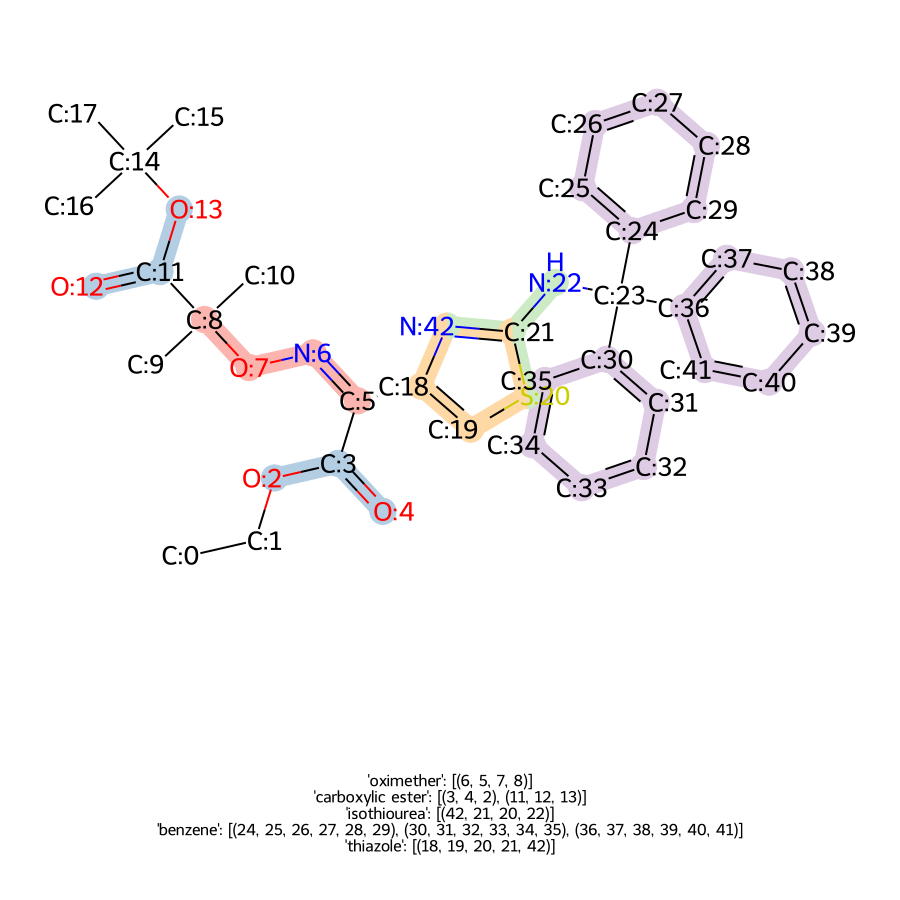

In [3]:
from accfg import AccFG, draw_mol_with_fgs, molimg
from accfg.draw import print_fg_tree

afg = AccFG(print_load_info=True, lite=True)

smi = "CCOC(=O)C(=NOC(C)(C)C(=O)OC(C)(C)C)c1csc(NC(c2ccccc2)(c2ccccc2)c2ccccc2)n1"

# show_atoms=True  -> 让输出带上“功能团命中的原子编号”
# show_graph=True  -> 返回 fg_graph（用于打印树/结构化组织）
fgs, fg_graph = afg.run(smi, show_atoms=True, show_graph=True)

# 打印“功能团树”（结构化 FG 视图）
print_fg_tree(fg_graph, fgs.keys(), show_atom_idx=True)

# 打印“顶层功能团字典”：{FG名: [(atom_idx_tuple), ...], ...}
print("\nTop level FGs:\n", fgs)

# Visualize the FGs on molecule
img = draw_mol_with_fgs(smi, afg=afg, img_size=(900, 900))
molimg(img) 

用 RDKit 高亮原子看看和 AccFG 的序号一不一样

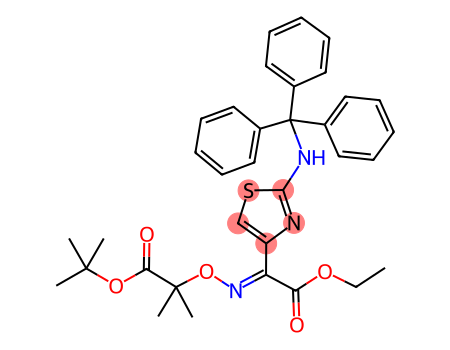

In [15]:
from rdkit import Chem
from rdkit.Chem import Draw

smiles = "CCOC(=O)C(=NOC(C)(C)C(=O)OC(C)(C)C)c1csc(NC(c2ccccc2)(c2ccccc2)c2ccccc2)n1"  # 阿司匹林举例
mol = Chem.MolFromSmiles(smiles)

highlight_atoms = [18, 19, 20, 21, 42]  # 你要高亮的原子序号（0-based）

img = Draw.MolToImage(
    mol,
    size=(450, 350),
    highlightAtoms=highlight_atoms,
    highlightAtomRadii={i: 0.35 for i in highlight_atoms},  # 可选：圈大一点
)

img  # 在 notebook 里直接显示；或 img.save("mol.png")


尝试用 RDKit 把对应原子序好的 SMILES Fragment 切出来

In [16]:
from rdkit import Chem

smi = "CCOC(=O)C(=NOC(C)(C)C(=O)OC(C)(C)C)c1csc(NC(c2ccccc2)(c2ccccc2)c2ccccc2)n1"
mol = Chem.MolFromSmiles(smi)

# 假设这是 AccFG 给你的一个功能团实例（原子编号元组）
fg_atoms = (18, 19, 20, 21, 42)   # 示例：换成你的 AccFG 输出

frag_smi = Chem.MolFragmentToSmiles(
    mol,
    atomsToUse=list(fg_atoms),
    isomericSmiles=True,
    canonical=False,   # 不强制重排，通常更便于对照
)
print(frag_smi)

c1cscn1


用 RDKit 把对应原子序好的 SMILES Fragment 切出来并且标记断点

In [17]:
from rdkit import Chem

def fg_fragment_with_attachment_points(smiles: str, fg_atoms: tuple[int, ...]):
    mol = Chem.MolFromSmiles(smiles)
    fg = set(fg_atoms)

    # 1) 找到所有“跨边界”的 bond（一个端点在 fg，另一个不在）
    cut_bond_ids = []
    cut_bonds = []
    for b in mol.GetBonds():
        a1, a2 = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        if (a1 in fg) ^ (a2 in fg):
            cut_bond_ids.append(b.GetIdx())
            cut_bonds.append((a1, a2))

    # 2) 断键并在断点加 dummy 原子（*）
    # FragmentOnBonds 会返回“一个整体 mol”，里面包含所有碎片，并用 dummy 标记断点  [oai_citation:3‡rdkit.readthedocs.io](https://rdkit.readthedocs.io/en/latest/GettingStartedInPython.html)
    frag_mol = Chem.FragmentOnBonds(mol, cut_bond_ids, addDummies=True)

    # 3) 把整体 mol 拆成各个连通分量
    # GetMolFrags(asMols=False) 会给每个碎片的 atom id 列表；asMols=True 则直接返回 Mol 对象  [oai_citation:4‡buildmedia.readthedocs.org](https://buildmedia.readthedocs.org/media/pdf/rdkit/latest/rdkit.pdf?utm_source=chatgpt.com)
    frags_atom_ids = Chem.GetMolFrags(frag_mol, asMols=False, sanitizeFrags=False)

    # 4) 选出“和 fg 重叠最多”的那个碎片（通常就是你的功能团那块 + dummy）
    best_ids = max(frags_atom_ids, key=lambda ids: len(fg.intersection(ids)))

    # 5) 输出该碎片的 SMILES（会包含 dummy 连接点）
    frag_smiles = Chem.MolFragmentToSmiles(
        frag_mol,
        atomsToUse=list(best_ids),
        isomericSmiles=True
    )

    # （可选）也可以看看“断开后的整分子”长啥样，通常是多个组分用 '.' 分开
    all_fragged_smiles = Chem.MolToSmiles(frag_mol, isomericSmiles=True)

    return frag_smiles, all_fragged_smiles, cut_bonds

# ---- 用法示例 ----
smi = "CCOC(=O)C(=NOC(C)(C)C(=O)OC(C)(C)C)c1csc(NC(c2ccccc2)(c2ccccc2)c2ccccc2)n1"
fg_atoms = (18, 19, 20, 21, 42)  # 这里换成 AccFG 给你的那组

frag_smi, all_smi, cut_bonds = fg_fragment_with_attachment_points(smi, fg_atoms)
print("边界键(原子对):", cut_bonds)
print("目标片段:", frag_smi)
print("全部断裂结果:", all_smi)

边界键(原子对): [(5, 18), (21, 22)]
目标片段: [5*]c1csc([22*])n1
全部断裂结果: [18*]C(=NOC(C)(C)C(=O)OC(C)(C)C)C(=O)OCC.[21*]NC(c1ccccc1)(c1ccccc1)c1ccccc1.[5*]c1csc([22*])n1


In [2]:
import numpy as np

a = np.array([0.6352, 0.5669, 0.6195])
print((a.min()+a.max())/2)
print(-(a.min()-a.max())/2)



0.60105
0.034150000000000014


#### Download Qwen3 chat template

In [ ]:
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained("Qwen/Qwen3-8B")

with open("agent/chat_templates/qwen3_chat_template.jinja", "w", encoding="utf-8") as f:
    f.write(tok.chat_template)

/home/tianang/anaconda3/envs/reasonv/lib/python3.11/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


### Intern-s1-mini AUROC and F1 relationship

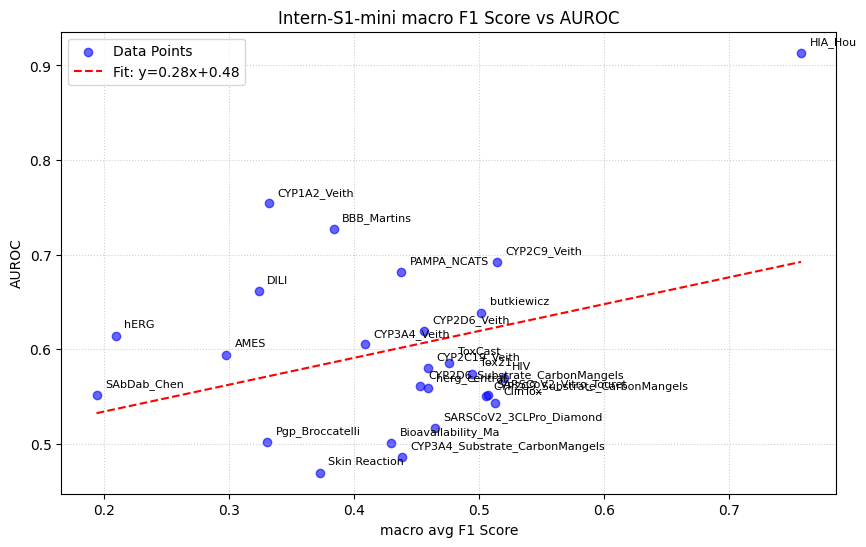

In [10]:
import matplotlib.pyplot as plt
import numpy as np

AUROC = [
    0.6140,
    0.5939,
    0.6611,
    0.4696,
    0.5854,
    0.5740,
    0.5431,
    0.5586,
    0.6815,
    0.9134,
    0.5012,
    0.7273,
    0.5023,
    0.7541,
    0.5803,
    0.6923,
    0.6193,
    0.6052, 
    0.5502,
    0.5612,
    0.4867,
    0.5697,
    0.5172,
    0.5518,
    0.6383,
    0.5519
]

F1 = [
    0.2096,
    0.2978,
    0.3239,
    0.3728,
    0.4765,
    0.4947,
    0.5127,
    0.4591,
    0.4378,
    0.7580,
    0.4300,
    0.3839,
    0.3306,
    0.3322,
    0.4596,
    0.5145,
    0.4559,
    0.4087,
    0.5054,
    0.4533,
    0.4384,
    0.5200,
    0.4650,
    0.5072,
    0.5020,
    0.1940
]

model_name = "Intern-S1-mini"

task_names = [
    'hERG',
    'AMES',
    'DILI',
    'Skin Reaction',
    'ToxCast',
    'Tox21',
    'ClinTox',
    'herg_central',
    'PAMPA_NCATS',
    'HIA_Hou',
    'Bioavailability_Ma',
    'BBB_Martins',
    'Pgp_Broccatelli',
    'CYP1A2_Veith',
    'CYP2C19_Veith',
    'CYP2C9_Veith',
    'CYP2D6_Veith',
    'CYP3A4_Veith',
    'CYP2C9_Substrate_CarbonMangels',
    'CYP2D6_Substrate_CarbonMangels',
    'CYP3A4_Substrate_CarbonMangels',
    'HIV',
    'SARSCoV2_3CLPro_Diamond',
    'SARSCoV2_Vitro_Touret',
    'butkiewicz',
    'SAbDab_Chen',
]

# 线性拟合 (1次多项式)
coefficients = np.polyfit(F1, AUROC, 1)
polynomial = np.poly1d(coefficients)
xs = np.linspace(min(F1), max(F1), 100)
ys = polynomial(xs)

# 绘图
plt.figure(figsize=(10, 6))
plt.scatter(F1, AUROC, color='blue', label='Data Points', alpha=0.6)

# ✅ 给每个点加上模型名字标注
for x, y, name in zip(F1, AUROC, task_names):
    plt.annotate(
        name,
        (x, y),
        textcoords="offset points",
        xytext=(6, 6),   # 文字偏移，避免盖住点
        ha='left',
        fontsize=8
    )

plt.plot(xs, ys, color='red', linestyle='--',
         label=f'Fit: y={coefficients[0]:.2f}x+{coefficients[1]:.2f}')

# 设置标签和标题
plt.xlabel('macro avg F1 Score')
plt.ylabel('AUROC')
plt.title(f'{model_name} macro F1 Score vs AUROC')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 显示图片
plt.show()

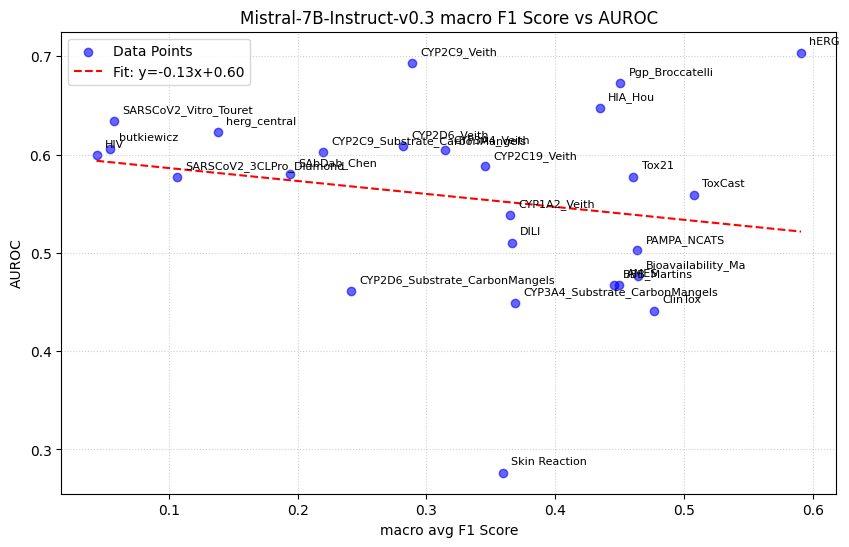

In [9]:
import matplotlib.pyplot as plt
import numpy as np

AUROC = [
    0.7037,
    0.4674,
    0.5102,
    0.2763,
    0.5593,
    0.5772,
    0.4413,
    0.6234,
    0.5025,
    0.6477,
    0.4762,
    0.4677,
    0.6732,
    0.5388,
    0.5881,
    0.6934,
    0.6089,
    0.6043,
    0.6026,
    0.4612,
    0.4488,
    0.5993,
    0.577,
    0.6342,
    0.606,
    0.5805
]

F1 = [
    0.5909,
    0.4492,
    0.3661,
    0.3594,
    0.5077,
    0.4608,
    0.4771,
    0.1379,
    0.4639,
    0.4348,
    0.4643,
    0.4458,
    0.4504,
    0.3647,
    0.3454,
    0.2889,
    0.2820,
    0.3145,
    0.2197,
    0.2416,
    0.3692,
    0.0439,
    0.1066,
    0.0577,
    0.0547,
    0.1940
]

model_name = "Mistral-7B-Instruct-v0.3"

task_names = [
    'hERG',
    'AMES',
    'DILI',
    'Skin Reaction',
    'ToxCast',
    'Tox21',
    'ClinTox',
    'herg_central',
    'PAMPA_NCATS',
    'HIA_Hou',
    'Bioavailability_Ma',
    'BBB_Martins',
    'Pgp_Broccatelli',
    'CYP1A2_Veith',
    'CYP2C19_Veith',
    'CYP2C9_Veith',
    'CYP2D6_Veith',
    'CYP3A4_Veith',
    'CYP2C9_Substrate_CarbonMangels',
    'CYP2D6_Substrate_CarbonMangels',
    'CYP3A4_Substrate_CarbonMangels',
    'HIV',
    'SARSCoV2_3CLPro_Diamond',
    'SARSCoV2_Vitro_Touret',
    'butkiewicz',
    'SAbDab_Chen',
]

# 线性拟合 (1次多项式)
coefficients = np.polyfit(F1, AUROC, 1)
polynomial = np.poly1d(coefficients)
xs = np.linspace(min(F1), max(F1), 100)
ys = polynomial(xs)

# 绘图
plt.figure(figsize=(10, 6))
plt.scatter(F1, AUROC, color='blue', label='Data Points', alpha=0.6)

# ✅ 给每个点加上模型名字标注
for x, y, name in zip(F1, AUROC, task_names):
    plt.annotate(
        name,
        (x, y),
        textcoords="offset points",
        xytext=(6, 6),   # 文字偏移，避免盖住点
        ha='left',
        fontsize=8
    )

plt.plot(xs, ys, color='red', linestyle='--',
         label=f'Fit: y={coefficients[0]:.2f}x+{coefficients[1]:.2f}')

# 设置标签和标题
plt.xlabel('macro avg F1 Score')
plt.ylabel('AUROC')
plt.title(f'{model_name} macro F1 Score vs AUROC')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 显示图片
plt.show()

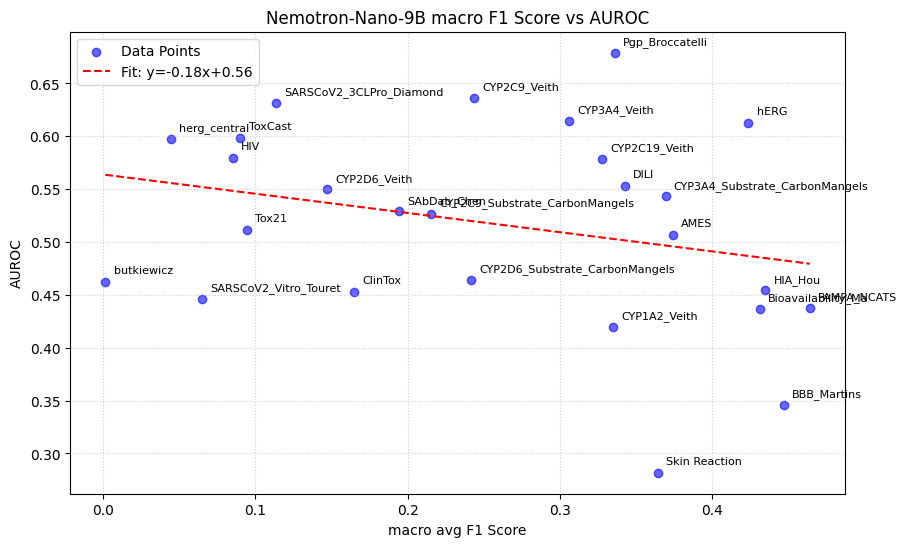

In [8]:
import matplotlib.pyplot as plt
import numpy as np

AUROC = [
    0.613,
    0.5067,
    0.553,
    0.2818,
    0.5984,
    0.5113,
    0.453,
    0.5972,
    0.4375,
    0.4543,
    0.4368,
    0.3461,
    0.6791,
    0.42,
    0.5789,
    0.6364,
    0.5498,
    0.6145,
    0.5266,
    0.4645,
    0.5432,
    0.5799,
    0.6313,
    0.4459,
    0.4625,
    0.529
]

F1 = [
    0.4236,
    0.3739,
    0.3425,
    0.3643,
    0.0900,
    0.0944,
    0.1649,
    0.0444,
    0.4639,
    0.4348,
    0.4311,
    0.4469,
    0.3360,
    0.3345,
    0.3273,
    0.2433,
    0.1469,
    0.3057,
    0.2151,
    0.2416,
    0.3692,
    0.0850,
    0.1136,
    0.0651,
    0.0014,
    0.1940
]

model_name = "Nemotron-Nano-9B"

task_names = [
    'hERG',
    'AMES',
    'DILI',
    'Skin Reaction',
    'ToxCast',
    'Tox21',
    'ClinTox',
    'herg_central',
    'PAMPA_NCATS',
    'HIA_Hou',
    'Bioavailability_Ma',
    'BBB_Martins',
    'Pgp_Broccatelli',
    'CYP1A2_Veith',
    'CYP2C19_Veith',
    'CYP2C9_Veith',
    'CYP2D6_Veith',
    'CYP3A4_Veith',
    'CYP2C9_Substrate_CarbonMangels',
    'CYP2D6_Substrate_CarbonMangels',
    'CYP3A4_Substrate_CarbonMangels',
    'HIV',
    'SARSCoV2_3CLPro_Diamond',
    'SARSCoV2_Vitro_Touret',
    'butkiewicz',
    'SAbDab_Chen',
]

# 线性拟合 (1次多项式)
coefficients = np.polyfit(F1, AUROC, 1)
polynomial = np.poly1d(coefficients)
xs = np.linspace(min(F1), max(F1), 100)
ys = polynomial(xs)

# 绘图
plt.figure(figsize=(10, 6))
plt.scatter(F1, AUROC, color='blue', label='Data Points', alpha=0.6)

# ✅ 给每个点加上模型名字标注
for x, y, name in zip(F1, AUROC, task_names):
    plt.annotate(
        name,
        (x, y),
        textcoords="offset points",
        xytext=(6, 6),   # 文字偏移，避免盖住点
        ha='left',
        fontsize=8
    )

plt.plot(xs, ys, color='red', linestyle='--',
         label=f'Fit: y={coefficients[0]:.2f}x+{coefficients[1]:.2f}')

# 设置标签和标题
plt.xlabel('macro avg F1 Score')
plt.ylabel('AUROC')
plt.title(f'{model_name} macro F1 Score vs AUROC')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 显示图片
plt.show()

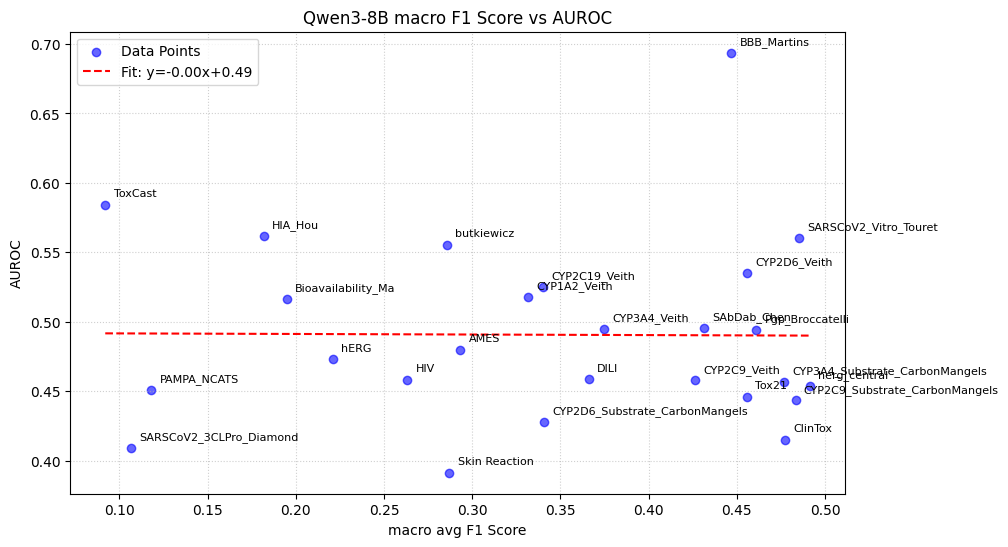

In [7]:
import matplotlib.pyplot as plt
import numpy as np

AUROC = [
    0.4729,
    0.4795,
    0.4585,
    0.3912,
    0.5841,
    0.4459,
    0.4151,
    0.4539,
    0.4507,
    0.5615,
    0.5163,
    0.6937,
    0.4943,
    0.5178,
    0.5253,
    0.4577,
    0.5353,
    0.4948,
    0.4433,
    0.4277,
    0.4569,
    0.4582,
    0.4089,
    0.5602,
    0.5553,
    0.4957
]

F1 = [
    0.2210,
    0.2932,
    0.3661,
    0.2870,
    0.0920,
    0.4558,
    0.4771,
    0.4914,
    0.1180,
    0.1818,
    0.1950,
    0.4469,
    0.4611,
    0.3318,
    0.3399,
    0.4264,
    0.4558,
    0.3748,
    0.4833,
    0.3406,
    0.4766,
    0.2633,
    0.1066,
    0.4854,
    0.2858,
    0.4316
]

model_name = 'Qwen3-8B'

task_names = [
    'hERG',
    'AMES',
    'DILI',
    'Skin Reaction',
    'ToxCast',
    'Tox21',
    'ClinTox',
    'herg_central',
    'PAMPA_NCATS',
    'HIA_Hou',
    'Bioavailability_Ma',
    'BBB_Martins',
    'Pgp_Broccatelli',
    'CYP1A2_Veith',
    'CYP2C19_Veith',
    'CYP2C9_Veith',
    'CYP2D6_Veith',
    'CYP3A4_Veith',
    'CYP2C9_Substrate_CarbonMangels',
    'CYP2D6_Substrate_CarbonMangels',
    'CYP3A4_Substrate_CarbonMangels',
    'HIV',
    'SARSCoV2_3CLPro_Diamond',
    'SARSCoV2_Vitro_Touret',
    'butkiewicz',
    'SAbDab_Chen',
]

# 线性拟合 (1次多项式)
coefficients = np.polyfit(F1, AUROC, 1)
polynomial = np.poly1d(coefficients)
xs = np.linspace(min(F1), max(F1), 100)
ys = polynomial(xs)

# 绘图
plt.figure(figsize=(10, 6))
plt.scatter(F1, AUROC, color='blue', label='Data Points', alpha=0.6)

# ✅ 给每个点加上模型名字标注
for x, y, name in zip(F1, AUROC, task_names):
    plt.annotate(
        name,
        (x, y),
        textcoords="offset points",
        xytext=(6, 6),   # 文字偏移，避免盖住点
        ha='left',
        fontsize=8
    )

plt.plot(xs, ys, color='red', linestyle='--',
         label=f'Fit: y={coefficients[0]:.2f}x+{coefficients[1]:.2f}')

# 设置标签和标题
plt.xlabel('macro avg F1 Score')
plt.ylabel('AUROC')
plt.title(f'{model_name} macro F1 Score vs AUROC')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 显示图片
plt.show()

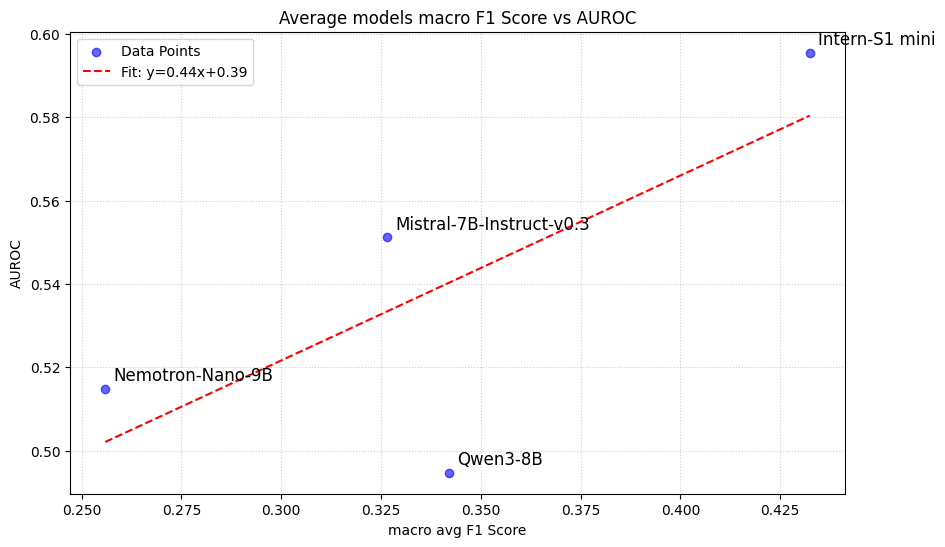

In [3]:
import matplotlib.pyplot as plt
import numpy as np

AUROC = [
    0.4947,
    0.5148,
    0.5512,
    0.5955
]

F1 = [
    0.3419,
    0.2559,
    0.3266,
    0.4324
]

Model_name = [
    'Qwen3-8B',
    'Nemotron-Nano-9B',
    'Mistral-7B-Instruct-v0.3',
    'Intern-S1 mini'
]

# 线性拟合 (1次多项式)
coefficients = np.polyfit(F1, AUROC, 1)
polynomial = np.poly1d(coefficients)
xs = np.linspace(min(F1), max(F1), 100)
ys = polynomial(xs)

# 绘图
plt.figure(figsize=(10, 6))
plt.scatter(F1, AUROC, color='blue', label='Data Points', alpha=0.6)

# ✅ 给每个点加上模型名字标注
for x, y, name in zip(F1, AUROC, Model_name):
    plt.annotate(
        name,
        (x, y),
        textcoords="offset points",
        xytext=(6, 6),   # 文字偏移，避免盖住点
        ha='left',
        fontsize=12
    )

plt.plot(xs, ys, color='red', linestyle='--',
         label=f'Fit: y={coefficients[0]:.2f}x+{coefficients[1]:.2f}')

# 设置标签和标题
plt.xlabel('macro avg F1 Score')
plt.ylabel('AUROC')
plt.title('Average models macro F1 Score vs AUROC')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 显示图片
plt.show()
